# EAUI 2026 — Procesamiento de datos

Carga, recodifica y prepara la Encuesta de Acceso y Uso de Internet SUBTEL 2026.

**Orden de ejecución:** Carga → GSE → Etiquetas → NS/NR → Renombrado → Recodificaciones → Funciones

## 1. Carga del archivo

In [ ]:
import pyreadstat
import re
import unicodedata
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import prince
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

df, meta = pyreadstat.read_sav("/Users/tomas/github/eaui_subtel/data/sav/2026.sav")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Filas: 5,000 | Columnas: 587


## 2. GSE derivado

Se calcula aquí con los nombres originales SPSS (`A10`, `A11`), antes de cualquier renombrado o recodificación.

In [81]:
def _educ_g(e):
    if pd.isna(e): return None
    e = int(e)
    if e <= 3:  return 'basica'
    if e <= 7:  return 'media'
    if e <= 9:  return 'tecnica'
    return 'universitaria'

_M = {
    (1,'basica'):'E',  (1,'media'):'E',  (1,'tecnica'):'D',  (1,'universitaria'):'D',
    (2,'basica'):'E',  (2,'media'):'D',  (2,'tecnica'):'D',  (2,'universitaria'):'C3',
    (3,'basica'):'D',  (3,'media'):'C3', (3,'tecnica'):'C3', (3,'universitaria'):'C2',
    (4,'basica'):'C3', (4,'media'):'C2', (4,'tecnica'):'C2', (4,'universitaria'):'C1',
    (5,'basica'):'C2', (5,'media'):'C1', (5,'tecnica'):'C1', (5,'universitaria'):'AB',
    (6,'basica'):'C1', (6,'media'):'AB', (6,'tecnica'):'AB', (6,'universitaria'):'AB',
}
_ORDEN_GSE = ['AB','C1','C2','C3','D','E']  # Invertido

_eg = df['A10'].apply(_educ_g)
df['gse'] = pd.Categorical(
    df['A11'].combine(_eg, lambda o, e: np.nan if pd.isna(o) or e is None else _M.get((int(o), e), np.nan)),
    categories=_ORDEN_GSE, ordered=True  # Aquí usa el orden invertido automáticamente
)
print('GSE:', df['gse'].value_counts().reindex(_ORDEN_GSE).to_dict())

GSE: {'AB': 342, 'C1': 533, 'C2': 988, 'C3': 1316, 'D': 833, 'E': 988}


## 3. Etiquetas limpias

Construye un diccionario `etiquetas_limpias` con la etiqueta útil de cada variable SPSS.
Usado en `analizar_rm()` y consultas.

In [82]:
def limpiar_etiqueta(label):
    """Extrae la parte descriptiva útil de una etiqueta SPSS."""
    if not label: return label
    label = label.strip()
    # Patrón B/C: empieza con código de variable (P3_1 .-, Q1.3.-)
    if re.match(r'^[A-Z]\w+[\._]\w+\s*\.-?', label):
        if ':' in label:
            r = label.split(':')[-1].strip()
            if r: return r
        if '?' in label:
            r = label.split('?')[-1].strip().lstrip(':').strip()
            if r: return r
        r = re.sub(r'^[A-Z]\w+[\._]\w+[\s\._\-]+', '', label).strip()
        return r.lstrip('.-').strip()
    # Patrón A: etiqueta + [pregunta padre] (corchete abre, cierre o no)
    if '[' in label:
        r = label[:label.index('[')].strip()
        return re.sub(r'^\d+[\.-]+\s*', '', r).strip()
    # Patrón D: numeración inicial
    return re.sub(r'^\d+[\.-]+\s*', '', label).strip()


etiquetas_limpias = {
    col: limpiar_etiqueta(label)
    for col, label in zip(meta.column_names, meta.column_labels) if label
}
print(f"Etiquetas procesadas: {len(etiquetas_limpias)}")

Etiquetas procesadas: 587


## 4. Diccionario de variables originales

In [83]:
diccionario = pd.DataFrame({'variable': meta.column_names, 'etiqueta': meta.column_labels})
diccionario.head(20)

,variable,etiqueta
0,REGISTRO,Número de registro
1,FECHAFIN,Fecha de fin de la entrevista
2,COD_REGION,Región
3,COMUNA_DEF,Comuna
4,ZONA,ZONA
5,A9,A9.- ¿Cuál es su parentesco con el Jefe /a de ...
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."
7,A11,A11.- Y ¿Cuál es la profesión o trabajo o acti...
8,A12_11,Aymara [A12.- ¿Algún miembro de este hogar per...
9,A12_2,Rapa-Nui [A12.- ¿Algún miembro de este hogar p...


In [84]:
# Buscar variable por nombre o fragmento de etiqueta
busqueda = 'A10'
diccionario[
    diccionario['variable'].str.contains(busqueda, case=False) |
    diccionario['etiqueta'].str.contains(busqueda, case=False, na=False)
]

,variable,etiqueta
6,A10,"A10.- Pensando en el jefe de hogar, ¿cuál fue ..."


In [166]:
# Ver categorías codificadas de una variable
variable = 'Q13'
labels = meta.variable_value_labels.get(variable, {})
if labels:
    for k, v in labels.items(): print(f'  {k} -> {v}')
else:
    print(f"'{variable}' no tiene etiquetas de valor.")

  1.0 -> Banda Ancha Fija O Wifi [Adsl / Cable Modem / FibraÓptica / Wisp]
  2.0 -> Banda Ancha Móvil [Bam]
  3.0 -> Internet Móvil Con Plan O Bolsa De Gigas/Megas De Un Teléfono Móvil [Smartphone] / Tablet
  4.0 -> Conexión Satelital


## 5. Tratamiento NS/NR

Variables de montos usan `9999999` como código NS/NR.

In [86]:
cols_nsnr = [
    'P11','Q7_4',
    'P17_1','P17_2','P17_3','P17_4','P17_5',
    'P19_1','P19_2','P19_3','P19_4',
    'Q40_1','Q40_2','Q40_3','Q40_4','Q40_5',
    'Q42','Q42_1'
]
for col in cols_nsnr:
    if col in df.columns: df[col] = df[col].replace(9999999, np.nan)
print('NS/NR reemplazados por NaN.')

NS/NR reemplazados por NaN.


## 6. Renombrado de variables

Asigna nombres cortos a las variables principales. `educ_jh` y `ocupacion_jh` se recodifican
aquí, antes de la sección 7, porque el GSE ya fue calculado con sus valores numéricos.

In [87]:
nombres_cortos = {
    'REGISTRO':'id', 'FECHAFIN':'fecha_fin', 'COD_REGION':'region', 'COMUNA_DEF':'comuna', 'ZONA':'zona',
    'A9':'parentesco_jh', 'A10':'educ_jh', 'A11':'ocupacion_jh', 'A12_1':'ingreso_hogar',
    'Q1':'parentesco', 'Q1_1':'edad', 'Q1_2':'sexo', 'Q1_3':'educ', 'Q1_4':'ocupacion_encuestado', 'Q2':'actividad',
    'P1':'acceso_internet_hogar', 'P2':'n_smartphones_hogar', 'P2_1':'n_computadores_hogar',
    'P10':'tipo_acceso_fijo', 'P11':'pago_mensual_internet', 'P11_3':'velocidad_contratada',
    'P11_4':'calidad_acceso', 'P11_5':'cuota_mensual_gb', 'P12_2':'tipo_plan', 'P12_1':'plan_movil_tipo',
    'P14':'razon_no_acceso_principal', 'P15':'disposicion_contratar_fijo',
    'Q5':'uso_computador', 'Q7':'uso_smartphone', 'Q7_1':'smartphone_propio',
    'Q7_3':'plan_movil_tipo_ind', 'Q7_4':'pago_mensual_movil',
    'Q9':'ultimo_uso_internet', 'Q10':'frecuencia_internet', 'Q11':'tiempo_diario_internet',
    'Q13':'tipo_acceso_mas_usado', 'Q14':'uso_internet_hogar', 'Q15':'frecuencia_internet_hogar',
    'Q16':'tiempo_diario_hogar', 'Q17':'uso_internet_fuera_hogar', 'Q18':'frecuencia_fuera_hogar',
    'Q19':'tiempo_diario_fuera_hogar',
    'Q23':'internet_facilita_trabajo', 'Q25':'internet_mejora_vida', 'Q27':'ultima_compra_online',
    'Q31':'percepcion_proteccion', 'Q30_1':'reg_control_legal', 'Q30_2':'reg_control_familia', 'Q30_3':'reg_autocontrol',
    'FE_HOGAR':'fe_hogar', 'FE_PERSONAS':'fe_personas', 'POND_HOGAR':'pond_hogar', 'POND_PERSONAS':'pond_personas',
}

df = df.rename(columns={k: v for k, v in nombres_cortos.items() if k in df.columns})

# Recodificación de educ_jh y ocupacion_jh (aquí, con valores numéricos aún intactos)
_mapa_educ = {
    1:'Sin educación formal', 2:'Básica incompleta', 3:'Básica completa',
    4:'Media CH incompleta', 5:'Media TP incompleta', 6:'Media CH completa', 7:'Media TP completa',
    8:'Superior técnica incompleta', 9:'Superior técnica completa',
    10:'Superior universitaria incompleta', 11:'Superior universitaria completa'
}
_mapa_ocup = {
    1:'Trabajos ocasionales e informales', 2:'Oficio menor - obrero no calificado',
    3:'Obrero calificado - microempresario', 4:'Empleado medio - técnico - prof. independiente',
    5:'Ejecutivo medio - prof. universitario', 6:'Alto ejecutivo - empresario - directivo'
}
df['educ_jh']              = df['educ_jh'].map(_mapa_educ)
df['ocupacion_jh']         = df['ocupacion_jh'].map(_mapa_ocup)
df['ocupacion_encuestado'] = df['ocupacion_encuestado'].map({**_mapa_ocup, 7:'Sin trabajo remunerado'})

print(f"Renombradas: {len(nombres_cortos)} | Columnas totales: {df.shape[1]}")

Renombradas: 53 | Columnas totales: 588


## 7. Recodificaciones

Sobreescribe variables con valores en texto. Sin sufijos `_rec` ni `_label`.

In [88]:
df = df.copy()

# Identificación
df['region'] = df['region'].map({
    1:'Tarapacá', 2:'Antofagasta', 3:'Atacama', 4:'Coquimbo', 5:'Valparaíso',
    6:"O'Higgins", 7:'Maule', 8:'Biobío', 9:'Araucanía', 10:'Los Lagos',
    11:'Aysén', 12:'Magallanes', 13:'Metropolitana', 14:'Los Ríos', 15:'Arica y Parinacota', 16:'Ñuble'
})
df['zona'] = df['zona'].map({1:'Urbana', 2:'Rural'})

# Sociodemográficas del entrevistado
df['sexo'] = df['sexo'].map({1:'Hombre', 2:'Mujer'})
df['educ'] = df['educ'].map(_mapa_educ)
df['educ_grupo'] = df['educ'].map({
    'Sin educación formal':'Básica o menos', 'Básica incompleta':'Básica o menos',
    'Básica completa':'Básica o menos', 'Media CH incompleta':'Media',
    'Media TP incompleta':'Media', 'Media CH completa':'Media', 'Media TP completa':'Media',
    'Superior técnica incompleta':'Superior', 'Superior técnica completa':'Superior',
    'Superior universitaria incompleta':'Superior', 'Superior universitaria completa':'Superior',
})
df['tramo_edad'] = pd.cut(df['edad'], bins=[0,17,29,44,59,200],
                          labels=['Menor de 18','18-29','30-44','45-59','60 y más'], right=True)
df['actividad'] = df['actividad'].map({
    1:'Trabajador independiente', 2:'Empleador/patrón', 3:'Empleado dependiente',
    4:'Familiar no remunerado', 5:'FFAA y de orden', 6:'Cesante',
    7:'Jubilado/pensionado', 8:'Estudiante', 9:'Labores del hogar'
})

# Acceso a internet
df['acceso_internet_hogar'] = df['acceso_internet_hogar'].map({1:'Sí', 2:'No'})
df['tipo_acceso_fijo'] = df['tipo_acceso_fijo'].map({
    1:'ADSL', 2:'Cable/Módem', 3:'Fibra óptica', 4:'Inalámbrica',
    5:'Satelital', 31:'WiFi', 32:'Antena', 33:'Banda ancha', 34:'Acceso telefónico', 88:'No sabe'
})
df['velocidad_contratada'] = df['velocidad_contratada'].map({
    1:'Hasta 10 Mbps', 2:'Más de 10 a 100 Mbps', 3:'Más de 100 a 500 Mbps',
    4:'Más de 500 Mbps a 1 Gbps', 5:'Más de 1 Gbps', 99:'NS/NR'
})
df['tipo_plan'] = df['tipo_plan'].map({
    1:'Banda ancha desnuda', 2:'BA + TV Cable', 3:'BA + Telefonía fija',
    4:'Triple pack (BA+TV+Tel)', 5:'Otros planes'
})

# Uso individual
df['uso_computador']  = df['uso_computador'].map({1:'Sí', 2:'No'})
df['uso_smartphone']  = df['uso_smartphone'].map({1:'Sí', 2:'No'})
df['ultimo_uso_internet'] = df['ultimo_uso_internet'].map({
    1:'Hoy', 2:'Entre 2 y 3 días', 3:'Entre 3 y 7 días', 4:'Entre 1 y 4 semanas',
    5:'Más de 4 semanas', 6:'Más de 12 meses', 7:'Nunca'
})
df['frecuencia_internet'] = df['frecuencia_internet'].map({
    1:'Todos los días', 2:'Varias veces por semana',
    3:'Al menos una vez al mes', 4:'Menos de una vez al mes'
})
df['tiempo_diario_internet'] = df['tiempo_diario_internet'].map({
    1:'Menos de 1 hora', 2:'Entre 1 y 2 horas', 3:'Entre 2 y 4 horas', 4:'Más de 4 horas'
})

# Percepciones
df['percepcion_proteccion']     = df['percepcion_proteccion'].map({
    1:'Muy protegido', 2:'Protegido', 3:'Desprotegido', 4:'Muy desprotegido', 99:'NS/NR'
})
df['internet_mejora_vida']      = df['internet_mejora_vida'].map({1:'Sí', 2:'No'})
df['internet_facilita_trabajo'] = df['internet_facilita_trabajo'].map({1:'Sí', 2:'No'})

print('Recodificaciones completadas.')
print(f"sexo: {df['sexo'].value_counts().to_dict()}")
print(f"acceso: {df['acceso_internet_hogar'].value_counts().to_dict()}")

Recodificaciones completadas.
sexo: {'Mujer': 2815, 'Hombre': 2185}
acceso: {'Sí': 4841, 'No': 159}


## 8. Ingreso del hogar

Los rangos varían según el tamaño del hogar. Se unifica calculando el punto medio de cada rango.

In [89]:
_rangos = {
    11:(0,129000),12:(130000,226000),13:(227000,393000),14:(394000,686000),15:(687000,1100000),16:(1200000,2000000),17:(2100000,None),
    21:(0,210000),22:(211000,366000),23:(367000,639000),24:(640000,1100000),25:(1200000,1900000),26:(2000000,3300000),27:(3400000,None),
    31:(0,279000),32:(280000,487000),33:(488000,849000),34:(850000,1400000),35:(1500000,2500000),36:(2600000,4500000),37:(4600000,None),
    41:(0,341000),42:(342000,595000),43:(596000,1000000),44:(1100000,1800000),45:(1900000,3100000),46:(3200000,5500000),47:(5600000,None),
    51:(0,399000),52:(400000,696000),53:(697000,1200000),54:(1300000,2100000),55:(2200000,3600000),56:(3700000,6400000),57:(6500000,None),
    61:(0,453000),62:(454000,791000),63:(792000,1300000),64:(1400000,2400000),65:(2500000,4100000),66:(4200000,7300000),67:(7400000,None),
    71:(0,505000),72:(506000,881000),73:(882000,1500000),74:(1600000,2600000),75:(2700000,4600000),76:(4700000,8100000),77:(8200000,None),
    81:(0,555000),82:(556000,967000),83:(968000,1600000),84:(1700000,2900000),85:(3000000,5100000),86:(5200000,8900000),87:(9000000,None),
    91:(0,602000),92:(603000,1000000),93:(1100000,1800000),94:(1900000,3100000),95:(3200000,5500000),96:(5600000,9700000),97:(9800000,None),
    101:(0,648000),102:(649000,1100000),103:(1200000,1900000),104:(2000000,3400000),105:(3500000,5900000),106:(6000000,10400000),107:(10500000,None),
}
_mapa_pm = {float(k): (v[0]*1.5 if v[1] is None else (v[0]+v[1])/2) for k, v in _rangos.items()}

df['ingreso_pm'] = df['ingreso_hogar'].map(_mapa_pm)
df['ingreso_tramo'] = pd.cut(
    df['ingreso_pm'],
    bins=[0, 384000, 540000, 798000, 1100000, 1700000, float('inf')],
    labels=['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
            '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    right=True
)
df['ingreso_grupo'] = df['ingreso_tramo'].map({
    'Hasta $384 mil':'Bajo', '$384 mil a $540 mil':'Bajo',
    '$540 mil a $798 mil':'Medio', '$798 mil a $1,1 millón':'Medio',
    '$1,1 millón a $1,7 millones':'Alto', 'Más de $1,7 millones':'Alto',
})

# Validación: promedio de ingreso debe subir de E a AB
(
    df.groupby('gse', observed=True)['ingreso_pm']
    .agg(N='count', Promedio='mean').reindex(_ORDEN_GSE).round(0).astype({'N':int,'Promedio':int})
)

,N,Promedio
gse,,
AB,286,2097505
C1,444,1389884
C2,826,986176
C3,1112,799533
D,704,650022
E,846,539833


## 9. Funciones de análisis ponderado

In [90]:
ORDEN_CATEGORIAS = {
    'sexo':         ['Hombre','Mujer'],
    'zona':         ['Urbana','Rural'],
    'region':       ['Tarapacá','Antofagasta','Atacama','Coquimbo','Valparaíso',"O'Higgins",'Maule',
                     'Biobío','Araucanía','Los Lagos','Aysén','Magallanes','Metropolitana',
                     'Los Ríos','Arica y Parinacota','Ñuble'],
    'educ':         ['Sin educación formal','Básica incompleta','Básica completa',
                     'Media CH incompleta','Media TP incompleta','Media CH completa','Media TP completa',
                     'Superior técnica incompleta','Superior técnica completa',
                     'Superior universitaria incompleta','Superior universitaria completa'],
    'educ_grupo':   ['Básica o menos','Media','Superior'],
    'tramo_edad':   ['Menor de 18','18-29','30-44','45-59','60 y más'],
    'actividad':    ['Trabajador independiente','Empleador/patrón','Empleado dependiente',
                     'Familiar no remunerado','FFAA y de orden','Cesante',
                     'Jubilado/pensionado','Estudiante','Labores del hogar'],
    'ocupacion_jh': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo'],
    'ocupacion_encuestado': ['Trabajos ocasionales e informales','Oficio menor - obrero no calificado',
                     'Obrero calificado - microempresario','Empleado medio - técnico - prof. independiente',
                     'Ejecutivo medio - prof. universitario','Alto ejecutivo - empresario - directivo',
                     'Sin trabajo remunerado'],
    'gse':              ['AB', 'C1', 'C2', 'C3', 'D', 'E'],
    'ingreso_tramo':    ['Hasta $384 mil','$384 mil a $540 mil','$540 mil a $798 mil',
                         '$798 mil a $1,1 millón','$1,1 millón a $1,7 millones','Más de $1,7 millones'],
    'ingreso_grupo':    ['Bajo','Medio','Alto'],
    'acceso_internet_hogar':    ['Sí','No'],
    'uso_computador':           ['Sí','No'],
    'uso_smartphone':           ['Sí','No'],
    'internet_mejora_vida':     ['Sí','No'],
    'internet_facilita_trabajo':['Sí','No'],
    'ultimo_uso_internet':      ['Hoy','Entre 2 y 3 días','Entre 3 y 7 días',
                                  'Entre 1 y 4 semanas','Más de 4 semanas','Más de 12 meses','Nunca'],
    'frecuencia_internet':      ['Todos los días','Varias veces por semana',
                                  'Al menos una vez al mes','Menos de una vez al mes'],
    'tiempo_diario_internet':   ['Menos de 1 hora','Entre 1 y 2 horas','Entre 2 y 4 horas','Más de 4 horas'],
    'percepcion_proteccion':    ['Muy protegido','Protegido','Desprotegido','Muy desprotegido','NS/NR'],
    'velocidad_contratada':     ['Hasta 10 Mbps','Más de 10 a 100 Mbps','Más de 100 a 500 Mbps',
                                  'Más de 500 Mbps a 1 Gbps','Más de 1 Gbps','NS/NR'],
}


def fordf(df_tabla, titulo=None):
    """Formato visual: enteros sin decimales, porcentajes con 1 decimal."""
    
    # 1. Identificar solo las columnas que son numéricas
    num_cols = df_tabla.select_dtypes(include=['number']).columns
    
    # 2. Aplicar el formato solo a esas columnas
    estilo = df_tabla.style.format({
        col: '{:,.0f}' if 'ponderado' in str(col).lower() or 'total' in str(col).lower() or str(col).startswith('n ') else '{:.1f}'
        for col in num_cols
    })
    
    if titulo: 
        estilo = estilo.set_caption(titulo)
        
    return estilo




def _ordenar(df_res, var, cruzada=False):
    if var not in ORDEN_CATEGORIAS: return df_res
    orden = ORDEN_CATEGORIAS[var]
    if cruzada:
        ok  = [v for v in orden if v in df_res.index]
        rst = [v for v in df_res.index if v not in ok and v != 'Total']
        fin = ok + rst + (['Total'] if 'Total' in df_res.index else [])
        return df_res.reindex(fin)
    ok  = [v for v in orden if v in df_res[var].values]
    rst = [v for v in df_res[var].values if v not in ok and v != 'Total']
    df_res[var] = pd.Categorical(df_res[var], categories=ok+rst+['Total'], ordered=True)
    return df_res.sort_values(var).reset_index(drop=True)


def dstats(data_df, variables, tipo='frecuencia', cruce=None, factor=None, transponer=False, estilo=True):
    """
    Análisis ponderado de variables simples.
    tipo: 'frecuencia' | 'cruzada' | 'promedio' | 'suma'
    Si estilo=True, retorna Styler formateado. Si es False, retorna el DataFrame puro.
    Ejemplo: dstats(df, 'sexo', tipo='frecuencia', factor='fe_personas', estilo=False)
    """
    if isinstance(variables, str): variables = [variables]
    for col in variables + [factor] + ([cruce] if cruce else []):
        if col not in data_df.columns:
            raise ValueError(f"Columna '{col}' no existe.")

    if tipo == 'frecuencia':
        var = variables[0]
        tot = data_df[factor].sum()
        res = data_df.groupby(var, observed=True)[factor].sum().reset_index().rename(columns={factor:'n_ponderado'})
        res['porcentaje'] = (res['n_ponderado'] / tot * 100).round(2)
        res = pd.concat([res, pd.DataFrame({var:['Total'],'n_ponderado':[res['n_ponderado'].sum()],'porcentaje':[res['porcentaje'].sum().round(2)]})], ignore_index=True)
        res = _ordenar(res, var).set_index(var)
        
        if estilo:
            titulo = f"Frecuencia: '{var}' — base ponderada: {tot:,.0f} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    if tipo == 'cruzada':
        var = variables[0]
        tot = data_df[factor].sum()
        t   = data_df.pivot_table(values=factor, index=var, columns=cruce, aggfunc='sum', fill_value=0, observed=False)
        tp  = t.div(t.sum(axis=0), axis=1).mul(100).round(2)
        if var in ORDEN_CATEGORIAS:
            of = [v for v in ORDEN_CATEGORIAS[var] if v in t.index];  t, tp = t.reindex(of), tp.reindex(of)
        if cruce in ORDEN_CATEGORIAS:
            oc = [v for v in ORDEN_CATEGORIAS[cruce] if v in t.columns]; t, tp = t[oc], tp[oc]
        if transponer: t, tp = t.T, tp.T
        t.loc['Total'], tp.loc['Total'] = t.sum(numeric_only=True), tp.sum(numeric_only=True).round(2)
        cols = [s for c in t.columns for s in [t[c].rename(f'n {c}'), tp[c].rename(f'% {c}')]]
        res = pd.concat(cols, axis=1)
        
        if estilo:
            titulo = f"Cruce: '{var}' según '{cruce}' — base ponderada: {tot:,.0f} ({factor})"
            return fordf(res, titulo=titulo)
        return res

    def _wavg(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round(np.average(d[v], weights=d[f]), 4)) if len(d) > 0 and d[f].sum() > 0 else np.nan

    def _wsum(sub, v, f):
        d = sub[[v, f]].dropna()
        return float(round((d[v]*d[f]).sum(), 4))

    fn = _wavg if tipo == 'promedio' else _wsum
    col_name = 'promedio_ponderado' if tipo == 'promedio' else 'suma_ponderada'

    if not cruce:
        res = pd.DataFrame([(v, fn(data_df, v, factor)) for v in variables], columns=['variable', col_name])
        
        if estilo:
            titulo = f"{tipo.capitalize()} de variables — factor: {factor}"
            return fordf(res, titulo=titulo)
        return res

    filas = {g: {v: fn(sg, v, factor) for v in variables} for g, sg in data_df.groupby(cruce, observed=True)}
    filas['Total'] = {v: fn(data_df, v, factor) for v in variables}
    res = pd.DataFrame(filas).T
    res.index.name = cruce
    if cruce in ORDEN_CATEGORIAS:
        ok  = [v for v in ORDEN_CATEGORIAS[cruce] if v in res.index]
        rst = [v for v in res.index if v not in ok and v != 'Total']
        res = res.reindex(ok + rst + ['Total'])
        
    if estilo:
        titulo = f"{tipo.capitalize()} cruzado por '{cruce}' — factor: {factor}"
        return fordf(res, titulo=titulo)
    return res


print('ORDEN_CATEGORIAS, fordf, dstats listos.')

ORDEN_CATEGORIAS, fordf, dstats listos.


## 10. Grupos de respuesta múltiple

In [91]:
_c = df.columns

GRUPOS_RM = {
    # Hogar
    'A12':  ('Pueblos indígenas o tribales (hogar)',            [c for c in _c if c.startswith('A12_') and not c.startswith('A12_1')]),
    'A13':  ('Condiciones permanentes de salud en el hogar',   [c for c in _c if c.startswith('A13_')]),
    'A14':  ('Situaciones laborales en el hogar',              [c for c in _c if c.startswith('A14_') and not c.endswith('_OTRA')]),
    # Acceso y conectividad
    'P3':   ('Dispositivos usados para acceder a internet',    [c for c in _c if c.startswith('P3_') and not c.endswith('_OTRA')]),
    'P4':   ('Formas de acceso pagado a internet en el hogar', [c for c in _c if c.startswith('P4_')]),
    'P6':   ('Razones para tener internet fijo',               [c for c in _c if c.startswith('P6_') and not c.startswith('P6_1_') and not c.endswith('_OTRA')]),
    'P6_1': ('Razones para tener internet móvil',              [c for c in _c if c.startswith('P6_1_')]),
    'P7':   ('Medidas de protección internet para menores',    [c for c in _c if c.startswith('P7_')]),
    'P9':   ('Dispositivos de uso personal de menores',        [c for c in _c if c.startswith('P9_')]),
    'P12':  ('Conexión móvil 4G/5G',                           ['P12_11','P12_21','P12_31','P12_41']),
    'P13':  ('Razones de no acceso a internet fijo',           [c for c in _c if c.startswith('P13_') and not c.endswith('_OTRA')]),
    'P16':  ('Equipos que le interesaría tener (sin internet)',[c for c in _c if c.startswith('P16_')]),
    # Uso individual
    'Q6':   ('¿Cómo aprendió a usar el computador?',           [c for c in _c if c.startswith('Q6_') and c not in ['Q6_1','Q6_OTRA']]),
    'Q7_2': ('Smartphone 4G/5G',                               ['Q7_2_1','Q7_2_2','Q7_2_3','Q7_2_4']),
    'Q8':   ('Habilidades digitales',                          [c for c in _c if c.startswith('Q8_')]),
    'Q11_1':('Lugares donde usó internet ayer',                [c for c in _c if c.startswith('Q11_1_')]),
    'Q12':  ('Tipos de acceso en últimos 3 meses',             [c for c in _c if c.startswith('Q12_')]),
    'Q20':  ('Lugares donde usó internet fuera del hogar',     [c for c in _c if c.startswith('Q20_')]),
    'Q21':  ('Actividades realizadas en internet',             [c for c in _c if c.startswith('Q21_') and c not in ['Q21_1','Q21_10','Q21_19','Q21_26','Q21_33','Q21_38','Q21_44']]),
    'Q28':  ('Bienes y servicios comprados en internet',       [c for c in _c if c.startswith('Q28_') and not c.endswith('_OTRA')]),
    'Q32':  ('Actividades de seguridad y privacidad',          [c for c in _c if c.startswith('Q32_') and not c.endswith('_OTRA')]),
    'Q33':  ('Problemas de seguridad sufridos',                [c for c in _c if c.startswith('Q33_') and not c.endswith('_OTRA')]),
    'Q34':  ('Razones de no uso de internet',                  [c for c in _c if c.startswith('Q34_') and not c.endswith('_OTRA')]),
    'Q37':  ('Actividades de internet realizadas por terceros',[c for c in _c if c.startswith('Q37_')]),
    'Q39':  ('Equipos que le interesaría tener (no usuarios)', [c for c in _c if c.startswith('Q39_')]),
}

def analizar_rm(grupo, factor='fe_hogar', top_n=None, estilo=True):
    """
    Analiza un grupo de respuesta múltiple.
    Si estilo=True, retorna tabla estilizada (HTML). Si es False, retorna el DataFrame puro.
    """
    if grupo not in GRUPOS_RM: 
        raise ValueError(f"Grupo '{grupo}' no existe.")
        
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    base = df.loc[df[cols].notna().any(axis=1), factor].sum()
    
    filas = [
        {'variable': c,
         'etiqueta': etiquetas_limpias.get(c, c),
         'n_ponderado': int(df.loc[df[c]==1, factor].sum()),
         'porcentaje': round(df.loc[df[c]==1, factor].sum() / base * 100, 1)}
        for c in cols
    ]
    res = pd.DataFrame(filas).sort_values('porcentaje', ascending=False).reset_index(drop=True)
    if top_n: res = res.head(top_n)
    res.index += 1
    
    if estilo:
        titulo_tabla = f"{desc} — base ponderada: {int(base):,} ({factor})"
        return fordf(res, titulo=titulo_tabla)
    return res

print("Grupos de respuesta múltiple disponibles:")
for k, (desc, cols) in GRUPOS_RM.items():
    cols_validas = [c for c in cols if c in df.columns]
    print(f"  '{k}': {desc} ({len(cols_validas)} opciones)")

Grupos de respuesta múltiple disponibles:
  'A12': Pueblos indígenas o tribales (hogar) (8 opciones)
  'A13': Condiciones permanentes de salud en el hogar (7 opciones)
  'A14': Situaciones laborales en el hogar (8 opciones)
  'P3': Dispositivos usados para acceder a internet (8 opciones)
  'P4': Formas de acceso pagado a internet en el hogar (5 opciones)
  'P6': Razones para tener internet fijo (13 opciones)
  'P6_1': Razones para tener internet móvil (13 opciones)
  'P7': Medidas de protección internet para menores (12 opciones)
  'P9': Dispositivos de uso personal de menores (4 opciones)
  'P12': Conexión móvil 4G/5G (4 opciones)
  'P13': Razones de no acceso a internet fijo (29 opciones)
  'P16': Equipos que le interesaría tener (sin internet) (5 opciones)
  'Q6': ¿Cómo aprendió a usar el computador? (12 opciones)
  'Q7_2': Smartphone 4G/5G (4 opciones)
  'Q8': Habilidades digitales (19 opciones)
  'Q11_1': Lugares donde usó internet ayer (9 opciones)
  'Q12': Tipos de acceso en últ

In [92]:
def analizar_rm_cruce(grupo, cruce, factor='fe_personas', estilo=True):
    """
    Analiza un grupo de respuesta múltiple cruzado por una variable demográfica.
    Si estilo=True, retorna tabla estilizada (HTML). Si es False, retorna el DataFrame puro.
    """
    if grupo not in GRUPOS_RM: 
        raise ValueError(f"Grupo '{grupo}' no existe.")
        
    desc, cols = GRUPOS_RM[grupo]
    cols = [c for c in cols if c in df.columns]
    
    base_cruce = df.loc[df[cols].notna().any(axis=1)].groupby(cruce, observed=True)[factor].sum()
    
    resultados = {}
    for categoria in base_cruce.index:
        base = base_cruce[categoria]
        df_cat = df[df[cruce] == categoria]
        
        pcts = {
            etiquetas_limpias.get(c, c): round((df_cat.loc[df_cat[c]==1, factor].sum() / base) * 100, 1) 
            if base > 0 else 0 
            for c in cols
        }
        resultados[categoria] = pcts
        
    res_df = pd.DataFrame(resultados)
    res_df = res_df.sort_values(by=res_df.columns[0], ascending=False)
    
    if estilo:
        titulo_tabla = f"{desc} cruzado por '{cruce}' — factor: {factor}"
        return fordf(res_df, titulo=titulo_tabla)
    return res_df

---
# Análisis

In [93]:
dstats(df, 'sexo', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
sexo,,
Hombre,"6,681,550",48.4
Mujer,"7,129,211",51.6
Total,"13,810,761",100.0


In [94]:
analizar_rm('Q8', factor='fe_personas')

,variable,etiqueta,n_ponderado,porcentaje
1,Q8_12,"Revisar redes sociales (Facebook, Instagram, Whatapps, Youtube, TikTok, etc)","11,282,482",84.9
2,Q8_15,Realizar videollamdas,"11,271,083",84.8
3,Q8_16,Enviar y recibir correos con o sin archivos adjuntos,"9,780,624",73.6
4,Q8_17,"Realizar transacciones bancarias, compras y pagos en línea","9,529,520",71.7
5,Q8_14,Editar fotografías o videos,"8,213,889",61.8
6,Q8_1,Uso de procesador de texto (ej: Word),"7,898,264",59.4
7,Q8_13,Subir contenidos o realizar posteos en redes sociales,"7,666,711",57.7
8,Q8_4,"Duplicar o transferir archivos entre dispositivos (cámaras digitales, celulares, reproductores de música) o en la nube","7,115,863",53.6
9,Q8_10,"Conectarme a sitios o aplicaciones para ver videos, series y película o escuchar música","7,043,538",53.0
10,Q8_5,"Conectar un nuevo dispositivo (como un router, cámara o impresora)","7,012,591",52.8


In [95]:
analizar_rm_cruce('A12', cruce='gse', factor='fe_personas')

,AB,C1,C2,C3,D,E
Mapuche,3.9,7.5,9.5,9.2,12.2,11.8
Kawéskar,0.7,0.0,0.0,0.0,0.0,0.0
Quechua,0.4,0.1,0.1,0.1,0.3,0.2
Colla,0.1,0.1,0.1,0.1,0.0,0.1
Rapa-Nui,0.0,0.0,0.0,0.0,0.0,0.0
Atacameño,0.0,0.2,0.3,0.2,0.2,0.2
Chango,0.0,0.0,0.1,0.0,0.0,0.3
Selk’nam,0.0,0.0,0.0,0.0,0.0,0.1


## 11. Habilidades digitales Q8 — clasificación por nivel

In [96]:
# Clasificación de habilidades Q8 por nivel de dificultad
# Criterio: nivel más alto alcanzado (jerárquico)
#
# Básico     — consumo y comunicación cotidiana (6 ítems)
# Intermedio — productividad, gestión y creación (9 ítems)
# Avanzado   — configuración técnica y programación (3 ítems)

Q8_BASICO = {
    'Q8_10': 'Streaming (video/música)',
    'Q8_11': 'Juegos en línea',
    'Q8_12': 'Revisar redes sociales',
    'Q8_13': 'Publicar en redes sociales',
    'Q8_15': 'Videollamadas',
    'Q8_16': 'Correo electrónico',
}
Q8_INTERMEDIO = {
    'Q8_1':  'Procesador de texto (Word)',
    'Q8_2':  'Planilla de cálculo (Excel)',
    'Q8_3':  'Presentaciones (PowerPoint)',
    'Q8_4':  'Transferir archivos / nube',
    'Q8_5':  'Conectar nuevo dispositivo',
    'Q8_6':  'Instalar y configurar apps',
    'Q8_14': 'Editar fotos o videos',
    'Q8_17': 'Transacciones y pagos en línea',
    'Q8_18': 'Uso de IA (ChatGPT, etc.)',
}
Q8_AVANZADO = {
    'Q8_7': 'Configurar seguridad del dispositivo',
    'Q8_8': 'Instalar SO / programar (Python, Java…)',
    'Q8_9': 'Crear un sitio web',
}

_cols_b  = list(Q8_BASICO)
_cols_i  = list(Q8_INTERMEDIO)
_cols_a  = list(Q8_AVANZADO)
_cols_q8 = _cols_b + _cols_i + _cols_a + ['Q8_19']

def _nivel(row):
    if row[_cols_a].eq(1).any():  return 'Avanzado'
    if row[_cols_i].eq(1).any():  return 'Intermedio'
    if row[_cols_b].eq(1).any():  return 'Básico'
    return 'Sin habilidades'

# Crear nivel_habilidades en df (5 000 filas)
# Quienes no respondieron Q8 caen en 'Sin habilidades' (eq(1) es False para NaN)
df['nivel_habilidades'] = df.apply(_nivel, axis=1)
mask_q8 = df[_cols_q8].notna().any(axis=1)  # máscara para la tabla de ítems Q8
base_q8 = int(mask_q8.sum())

# Distribución sin ponderar (descriptiva)
orden_nivel = ['Avanzado', 'Intermedio', 'Básico', 'Sin habilidades']
dist = df['nivel_habilidades'].value_counts().reindex(orden_nivel)
print(f"Base: {len(df):,} (total df) | respondentes Q8: {base_q8:,}\n")
print("Distribución (sin ponderar):")
for niv, n in dist.items():
    pct = n / len(df) * 100
    print(f"  {niv:<20} {n:>5,}  ({pct:.1f}%)")

# Tabla de habilidades por nivel (base: respondentes Q8)
print("\n── Habilidades por nivel ──────────────────────────────────────────────")
for nivel, items in [('BÁSICO', Q8_BASICO), ('INTERMEDIO', Q8_INTERMEDIO), ('AVANZADO', Q8_AVANZADO)]:
    print(f"\n{nivel}")
    for cod, desc in items.items():
        n = int((df.loc[mask_q8, cod] == 1).sum())
        pct = n / base_q8 * 100
        print(f"  {cod:<8} {desc:<45}  {n:>5,} ({pct:.1f}%)")


Base: 5,000 (total df) | respondentes Q8: 4,758

Distribución (sin ponderar):
  Avanzado             1,548  (31.0%)
  Intermedio           2,226  (44.5%)
  Básico                 805  (16.1%)
  Sin habilidades        421  (8.4%)

── Habilidades por nivel ──────────────────────────────────────────────

BÁSICO
  Q8_10    Streaming (video/música)                       2,004 (42.1%)
  Q8_11    Juegos en línea                                1,646 (34.6%)
  Q8_12    Revisar redes sociales                         3,890 (81.8%)
  Q8_13    Publicar en redes sociales                     2,352 (49.4%)
  Q8_15    Videollamadas                                  3,886 (81.7%)
  Q8_16    Correo electrónico                             3,086 (64.9%)

INTERMEDIO
  Q8_1     Procesador de texto (Word)                     2,414 (50.7%)
  Q8_2     Planilla de cálculo (Excel)                    2,033 (42.7%)
  Q8_3     Presentaciones (PowerPoint)                    1,995 (41.9%)
  Q8_4     Transferir archivos

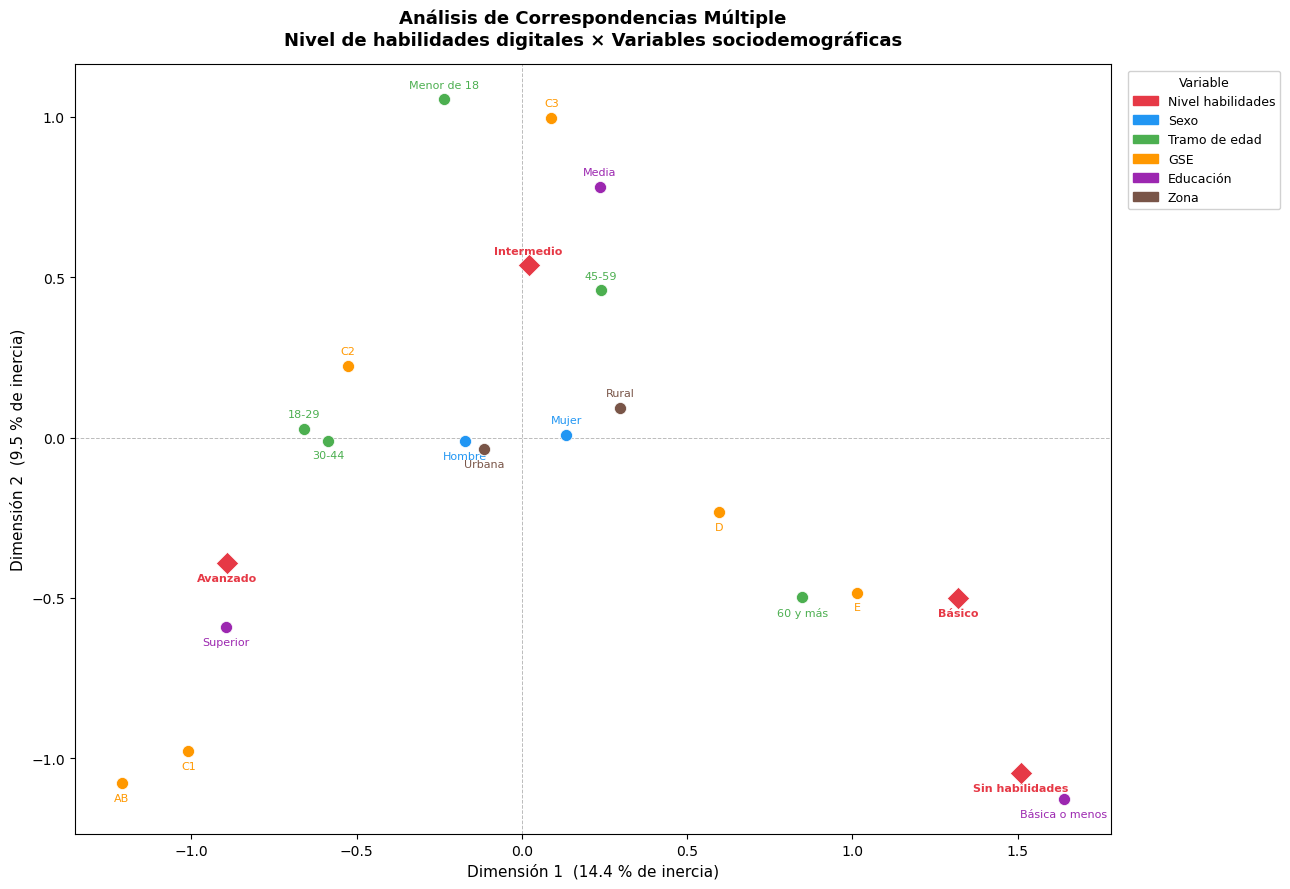


Inercia: Dim1 = 14.4%  |  Dim2 = 9.5%  |  Acumulada = 23.9%
Base ACM: 4,758 observaciones (complete cases sobre 4,758 respondentes Q8)


In [97]:
# ── Variables para el ACM ────────────────────────────────────────────────────
VAR_SOCIO = ['sexo', 'tramo_edad', 'gse', 'educ_grupo', 'zona']
VAR_ACM   = ['nivel_habilidades'] + VAR_SOCIO

df_acm = df.loc[mask_q8, VAR_ACM].dropna().copy()
for col in VAR_ACM:
    df_acm[col] = df_acm[col].astype(str)

# ── Ajuste del ACM ───────────────────────────────────────────────────────────
mca = prince.MCA(n_components=2, n_iter=10, random_state=42)
mca.fit(df_acm)

col_coords = mca.column_coordinates(df_acm)   # índice: 'variable__categoria'
dim1_pct   = mca.eigenvalues_[0] / mca.total_inertia_ * 100
dim2_pct   = mca.eigenvalues_[1] / mca.total_inertia_ * 100

# ── Parsear 'variable__categoria' ────────────────────────────────────────────
def _parse_idx(idx, vars_list):
    for v in sorted(vars_list, key=len, reverse=True):
        if idx.startswith(v + '__'):
            return v, idx[len(v) + 2:]
    return None, idx

parsed = {idx: _parse_idx(idx, VAR_ACM) for idx in col_coords.index}

# ── Paleta y etiquetas ───────────────────────────────────────────────────────
PALETA = {
    'nivel_habilidades': '#E63946',
    'sexo':              '#2196F3',
    'tramo_edad':        '#4CAF50',
    'gse':               '#FF9800',
    'educ_grupo':        '#9C27B0',
    'zona':              '#795548',
}
ETIQ_VAR = {
    'nivel_habilidades': 'Nivel habilidades',
    'sexo':              'Sexo',
    'tramo_edad':        'Tramo de edad',
    'gse':               'GSE',
    'educ_grupo':        'Educación',
    'zona':              'Zona',
}

# ── Biplot (coordenadas de categorías) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

for idx_val, (var, cat) in parsed.items():
    if var is None:
        continue
    x = float(col_coords.loc[idx_val, 0])
    y = float(col_coords.loc[idx_val, 1])
    color  = PALETA[var]
    marker = 'D' if var == 'nivel_habilidades' else 'o'
    size   = 130 if var == 'nivel_habilidades' else 75
    fw     = 'bold' if var == 'nivel_habilidades' else 'normal'

    ax.scatter(x, y, c=color, s=size, marker=marker, zorder=5,
               edgecolors='white', linewidths=0.5)

    va   = 'bottom' if y >= 0 else 'top'
    yoff = 7 if y >= 0 else -7
    ax.annotate(cat, (x, y), fontsize=8, ha='center', va=va,
                xytext=(0, yoff), textcoords='offset points',
                color=color, fontweight=fw)

ax.axhline(0, color='#bbb', lw=0.7, ls='--')
ax.axvline(0, color='#bbb', lw=0.7, ls='--')
ax.set_xlabel(f'Dimensión 1  ({dim1_pct:.1f} % de inercia)', fontsize=11)
ax.set_ylabel(f'Dimensión 2  ({dim2_pct:.1f} % de inercia)', fontsize=11)
ax.set_title(
    'Análisis de Correspondencias Múltiple\n'
    'Nivel de habilidades digitales × Variables sociodemográficas',
    fontsize=13, fontweight='bold', pad=14,
)

handles = [mpatches.Patch(color=PALETA[v], label=ETIQ_VAR[v]) for v in VAR_ACM]
ax.legend(handles=handles, title='Variable', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=9, title_fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"\nInercia: Dim1 = {dim1_pct:.1f}%  |  Dim2 = {dim2_pct:.1f}%  |  Acumulada = {dim1_pct + dim2_pct:.1f}%")
print(f"Base ACM: {len(df_acm):,} observaciones (complete cases sobre {base_q8:,} respondentes Q8)")

# **Generador de gráficos**

In [98]:
def generar_grafico(variable, cruce=None, factor=None, titulo=None, figsize=(11, 6),
                    tipo='barras_agrupadas', palette='viridis'):
    """
    Genera gráficos ponderados usando dstats y ORDEN_CATEGORIAS del notebook.

    Parámetros:
    - variable: Variable a analizar (str)
    - cruce: Variable para cruzar (str, opcional). Si None, muestra distribución simple
    - factor: Peso — 'fe_hogar' o 'fe_personas'. Si None, usa 'fe_personas'
    - titulo: Título del gráfico (str). Si None, se genera automáticamente
    - figsize: Tamaño figura (tuple)
    - tipo: 'barras_agrupadas' (default) o 'barras_apiladas'
    - palette: Paleta seaborn ('deep', 'muted', 'husl', etc.)

    Ejemplo:
    - generar_grafico('acceso_internet_hogar', cruce='gse', factor='fe_hogar')
    - generar_grafico('sexo', factor='fe_personas')
    - generar_grafico('velocidad_contratada', cruce='zona', factor='fe_hogar')
    """

    if factor is None:
        factor = 'fe_personas'

    if cruce is None:
        # Distribución simple
        res = dstats(df, variable, tipo='frecuencia', factor=factor, estilo=False)
        res = res.drop('Total', errors='ignore')

        # Ordenar según ORDEN_CATEGORIAS
        if variable in ORDEN_CATEGORIAS:
            orden = [v for v in ORDEN_CATEGORIAS[variable] if v in res.index]
            res = res.reindex(orden)

        fig, ax = plt.subplots(figsize=figsize)
        colors = sns.color_palette(palette, len(res))

        ax.bar(res.index, res['porcentaje'].values, color=colors, edgecolor='black', linewidth=0)

        # Añadir valores sobre barras (solo porcentaje)
        for i, (idx, pct) in enumerate(zip(res.index, res['porcentaje'].values)):
            ax.text(i, pct, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

        ax.set_ylabel('Porcentaje (%)', fontsize=11)
        ax.set_xlabel('', fontsize=0)
        if titulo is None:
            titulo = f"Distribución: {variable} (factor: {factor})"
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
        ax.set_ylim(0, 105)
        sns.despine(ax=ax, left=False, bottom=False)
        ax.grid(False)

    else:
        # Cruce — barras agrupadas o apiladas
        res = dstats(df, variable, tipo='cruzada', cruce=cruce, factor=factor, estilo=False)
        res = res.drop('Total', errors='ignore')

        # Ordenar filas y columnas según ORDEN_CATEGORIAS
        if variable in ORDEN_CATEGORIAS:
            orden_var = [v for v in ORDEN_CATEGORIAS[variable] if v in res.index]
            res = res.reindex(orden_var)

        if cruce in ORDEN_CATEGORIAS:
            orden_cruce = [v for v in ORDEN_CATEGORIAS[cruce] if v in
                          [c.replace('% ', '').replace('n ', '') for c in res.columns]]
            # Reconstruir columnas ordenadas
            cols_ordenadas = []
            for cat in orden_cruce:
                for col in res.columns:
                    if cat in col:
                        cols_ordenadas.append(col)
            res = res[[c for c in cols_ordenadas if c in res.columns]]

        # Extraer solo porcentajes
        pct_cols = [c for c in res.columns if c.startswith('% ')]
        pct_data = res[pct_cols].copy()
        pct_data.columns = [c.replace('% ', '') for c in pct_data.columns]

        fig, ax = plt.subplots(figsize=figsize)

        if tipo == 'barras_apiladas':
            pct_data.plot(kind='bar', stacked=True, ax=ax,
                         color=sns.color_palette(palette, len(pct_data.columns)),
                         edgecolor='black', linewidth=0, width=0.7)
            ax.set_ylabel('Porcentaje (%)', fontsize=11)
        else:
            # Barras agrupadas
            x = np.arange(len(pct_data.index))
            width = 0.8 / len(pct_data.columns)
            colors = sns.color_palette(palette, len(pct_data.columns))

            for i, col in enumerate(pct_data.columns):
                offset = (i - len(pct_data.columns)/2 + 0.5) * width
                ax.bar(x + offset, pct_data[col].values, width, label=col,
                      color=colors[i], edgecolor='black', linewidth=0)

                # Valores sobre barras (solo porcentaje)
                for j, val in enumerate(pct_data[col].values):
                    if val > 0:
                        ax.text(x[j] + offset, val, f'{val:.1f}%', ha='center', va='bottom',
                               fontsize=8, fontweight='bold')

            ax.set_xticks(x)
            ax.set_xticklabels(pct_data.index, rotation=0, ha='center')
            ax.set_ylabel('Porcentaje (%)', fontsize=11)
            ax.legend(title=cruce, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

        ax.set_xlabel('', fontsize=0)
        if titulo is None:
            titulo = f"{variable} según {cruce} (factor: {factor})"
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
        ax.set_ylim(0, 105)
        sns.despine(ax=ax, left=False, bottom=False)
        ax.grid(False)

    plt.tight_layout()
    plt.show()

    return fig, ax

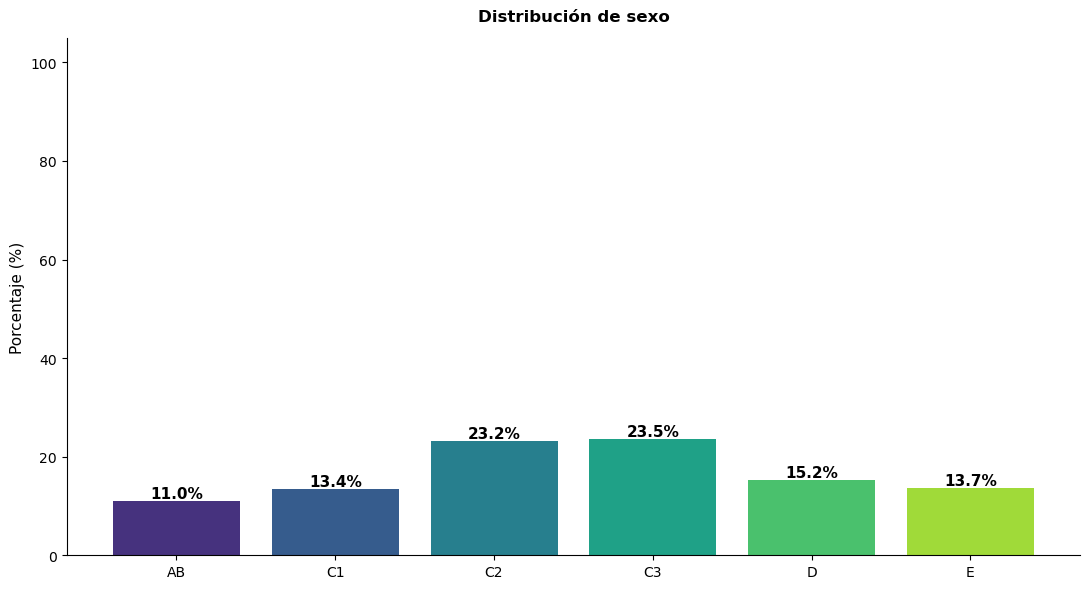

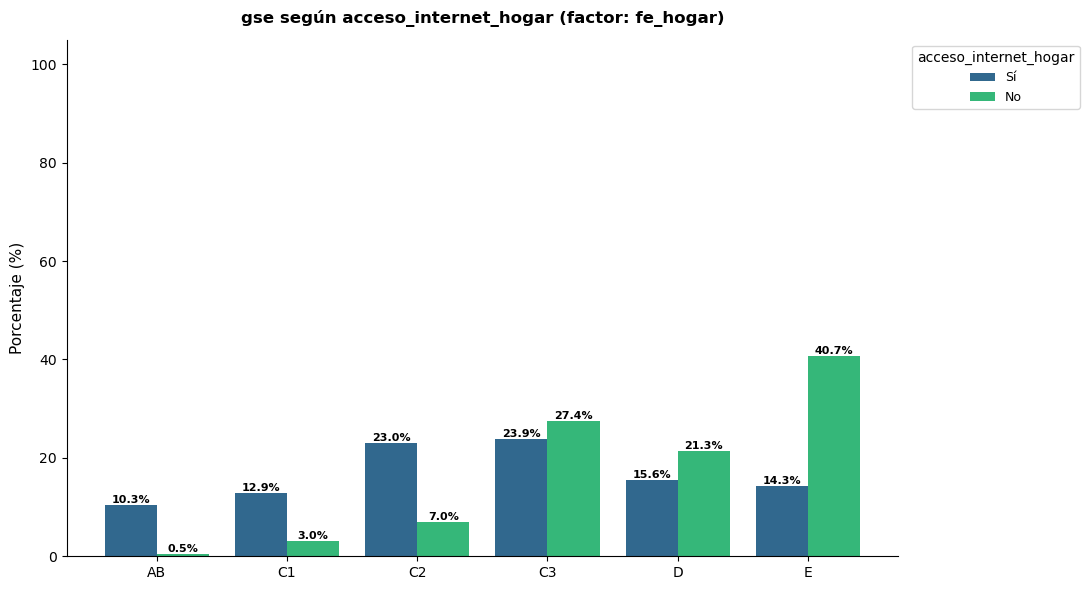

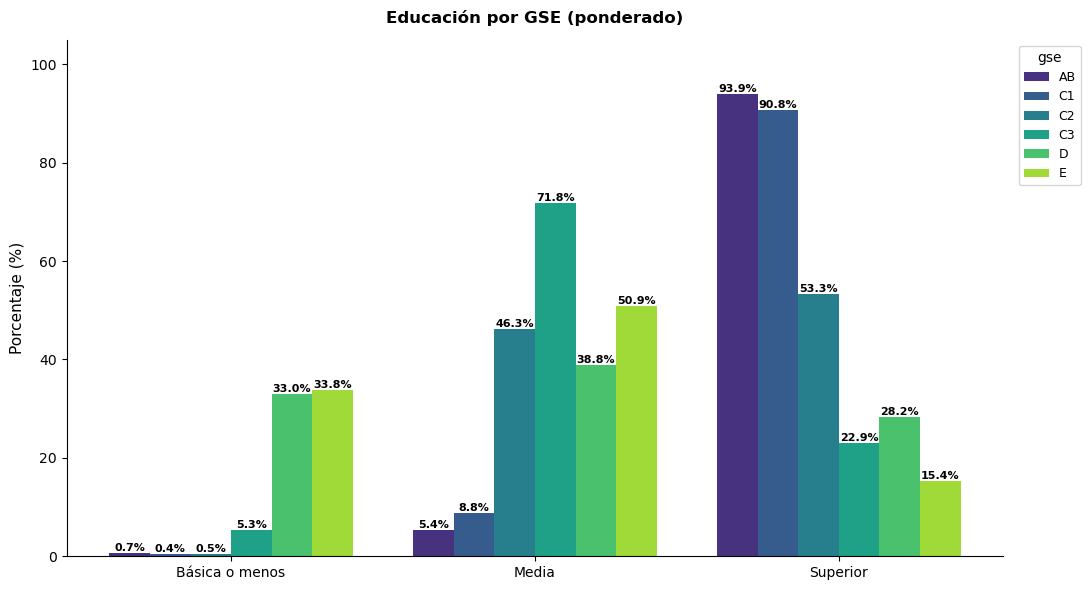

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'Educación por GSE (ponderado)'}, ylabel='Porcentaje (%)'>)

In [99]:
# Ejemplos de uso de generar_grafico

# Distribución simple
generar_grafico('gse', factor='fe_personas', titulo='Distribución de sexo')

# Cruce simple (barras agrupadas)
generar_grafico('gse', cruce='acceso_internet_hogar', factor='fe_hogar')

# Cruce con barras apiladas
# Personalizar título y paleta
generar_grafico('educ_grupo', cruce='gse', factor='fe_personas', 
                titulo='Educación por GSE (ponderado)', palette='viridis')


In [100]:
# ── Categorización de Habilidades Digitales (Q8) ──────────────────

# 1. Definimos el mapeo de categorías según el propósito de la tarea
categorizacion_habilidades = {
    'RRSS y Comunicación': ['Q8_12', 'Q8_13', 'Q8_15', 'Q8_16'],
    'Ofimática': ['Q8_1', 'Q8_2', 'Q8_3'],
    'Mantenimiento/Configuración': ['Q8_4', 'Q8_5', 'Q8_6'],
    'Creación de contenido': ['Q8_14', 'Q8_9'],
    'Seguridad': ['Q8_7'],
    'Habilidades Avanzadas': ['Q8_8', 'Q8_18'],
    'Consumo, transacciones y entretenimiento':  ['Q8_10', 'Q8_17', 'Q8_11']
}

# 2. Creamos las nuevas variables agregadas en el DataFrame
# Una persona tendrá un '1' en la categoría si posee al menos UNA de las habilidades del grupo.
cat_cols = []
for cat, cols in categorizacion_habilidades.items():
    # Generar nombre de columna técnico (ej: cat_habilidades_de_comunicacion)
    col_name = 'cat_' + cat.lower().replace(' ', '_').replace('/', '_').replace('ó', 'o').replace('á', 'a').replace('é', 'e')
    
    # Creamos la variable binaria (0 o 1)
    df[col_name] = df[cols].any(axis=1).astype(float)
    
    # Registramos la etiqueta limpia para que las tablas se vean bien
    etiquetas_limpias[col_name] = cat
    cat_cols.append(col_name)

# 3. Registramos este nuevo grupo en tu diccionario GRUPOS_RM
# Esto permite usar la función analizar_rm() que ya tienes definida.
GRUPOS_RM['Q8_CAT'] = ('Categorías de Habilidades Digitales (Agregadas)', cat_cols)

# 4. Ejecutamos el análisis ponderado por personas
analizar_rm('Q8_CAT', factor='fe_personas')


,variable,etiqueta,n_ponderado,porcentaje
1,cat_rrss_y_comunicacion,RRSS y Comunicación,"12,563,005",91.0
2,"cat_consumo,_transacciones_y_entretenimiento","Consumo, transacciones y entretenimiento","10,756,559",77.9
3,cat_mantenimiento_configuracion,Mantenimiento/Configuración,"8,560,861",62.0
4,cat_ofimatica,Ofimática,"8,527,140",61.7
5,cat_creacion_de_contenido,Creación de contenido,"8,386,081",60.7
6,cat_habilidades_avanzadas,Habilidades Avanzadas,"5,985,633",43.3
7,cat_seguridad,Seguridad,"5,125,336",37.1


In [101]:
analizar_rm_cruce('Q8_CAT', cruce='sexo', factor='fe_personas')

,Hombre,Mujer
RRSS y Comunicación,90.9,91.0
"Consumo, transacciones y entretenimiento",80.2,75.7
Mantenimiento/Configuración,68.6,55.8
Ofimática,67.2,56.6
Creación de contenido,63.3,58.3
Habilidades Avanzadas,49.8,37.3
Seguridad,45.0,29.8


## 12. Perfil sociodemográfico de la muestra

Estadísticas descriptivas basales de la población entrevistada.

In [102]:
# Sexo × Tramo de edad (cruce)
dstats(df, 'sexo', tipo='cruzada', cruce='tramo_edad', factor='fe_personas', estilo=True)

,n Menor de 18,% Menor de 18,n 18-29,% 18-29,n 30-44,% 30-44,n 45-59,% 45-59,n 60 y más,% 60 y más
sexo,,,,,,,,,,
Hombre,"109,111",65.9,"1,905,542",53.5,"1,957,706",47.5,"1,336,882",45.9,"1,372,310",45.0
Mujer,"56,553",34.1,"1,657,495",46.5,"2,165,178",52.5,"1,572,966",54.1,"1,677,019",55.0
Total,"165,664",100.0,"3,563,036",100.0,"4,122,884",100.0,"2,909,848",100.0,"3,049,329",100.0


In [103]:
# Zona (urbana/rural)
dstats(df, 'zona', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
zona,,
Urbana,"12,101,681",87.6
Rural,"1,709,080",12.4
Total,"13,810,761",100.0


In [104]:
# Región
dstats(df, 'region', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
region,,
Tarapacá,"248,518",1.8
Antofagasta,"471,322",3.4
Atacama,"216,306",1.6
Coquimbo,"582,250",4.2
Valparaíso,"1,445,401",10.5
O'Higgins,"711,803",5.2
Maule,"817,186",5.9
Biobío,"1,219,563",8.8
Araucanía,"743,482",5.4


In [105]:
# Educación grupos
dstats(df, 'educ_grupo', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
educ_grupo,,
Básica o menos,"1,534,173",11.1
Media,"5,836,419",42.3
Superior,"6,440,169",46.6
Total,"13,810,761",100.0


In [106]:
# GSE
dstats(df, 'gse', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
gse,,
AB,"1,522,010",11.0
C1,"1,845,934",13.4
C2,"3,203,799",23.2
C3,"3,251,371",23.5
D,"2,095,975",15.2
E,"1,891,672",13.7
Total,"13,810,761",100.0


In [107]:
# Ingreso (grupos)
dstats(df, 'ingreso_grupo', tipo='frecuencia', factor='fe_hogar', estilo=True)

,n_ponderado,porcentaje
ingreso_grupo,,
Bajo,"1,861,262",32.9
Medio,"1,349,054",23.9
Alto,"1,333,920",23.6
Total,"4,544,236",80.4


## 13. Acceso a internet en el hogar — variable dependiente

Caracterizar la variable dependiente central y sus brechas demográficas.

In [108]:
# Acceso internet hogar — frecuencia
dstats(df, 'acceso_internet_hogar', tipo='frecuencia', factor='fe_hogar', estilo=True)

,n_ponderado,porcentaje
acceso_internet_hogar,,
Sí,"5,457,486",96.6
No,"194,151",3.4
Total,"5,651,637",100.0


In [109]:
# Acceso × GSE (brecha principal)
dstats(df, 'acceso_internet_hogar', tipo='cruzada', cruce='gse', factor='fe_hogar', estilo=True)

,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
acceso_internet_hogar,,,,,,,,,,,,
Sí,"564,938",99.8,"705,229",99.2,"1,254,131",98.9,"1,302,498",96.1,"849,683",95.3,"781,007",90.8
No,899,0.2,"5,896",0.8,"13,612",1.1,"53,223",3.9,"41,430",4.7,"79,091",9.2
Total,"565,837",100.0,"711,125",100.0,"1,267,744",100.0,"1,355,721",100.0,"891,113",100.0,"860,097",100.0


In [110]:
# Acceso × Zona
dstats(df, 'acceso_internet_hogar', tipo='cruzada', cruce='zona', factor='fe_hogar', estilo=True)

,n Urbana,% Urbana,n Rural,% Rural
acceso_internet_hogar,,,,
Sí,"4,792,411",96.8,"665,075",95.1
No,"159,888",3.2,"34,263",4.9
Total,"4,952,299",100.0,"699,338",100.0


In [111]:
# Acceso × Región (top 8 regiones por población)
dstats(df, 'acceso_internet_hogar', tipo='cruzada', cruce='region', factor='fe_hogar', estilo=True)

,n Tarapacá,% Tarapacá,n Antofagasta,% Antofagasta,n Atacama,% Atacama,n Coquimbo,% Coquimbo,n Valparaíso,% Valparaíso,n O'Higgins,% O'Higgins,n Maule,% Maule,n Biobío,% Biobío,n Araucanía,% Araucanía,n Los Lagos,% Los Lagos,n Aysén,% Aysén,n Magallanes,% Magallanes,n Metropolitana,% Metropolitana,n Los Ríos,% Los Ríos,n Arica y Parinacota,% Arica y Parinacota,n Ñuble,% Ñuble
acceso_internet_hogar,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Sí,"96,383",98.7,"169,471",97.2,"87,853",99.0,"235,887",98.2,"590,468",97.0,"294,220",97.5,"341,613",97.2,"472,938",93.2,"306,094",96.4,"266,535",96.0,"34,336",99.2,"52,018",96.6,"2,164,430",96.7,"125,035",96.9,"62,890",94.1,"157,315",96.1
No,"1,310",1.3,"4,843",2.8,853,1.0,"4,430",1.8,"18,481",3.0,"7,497",2.5,"9,896",2.8,"34,303",6.8,"11,431",3.6,"10,947",4.0,273,0.8,"1,814",3.4,"73,749",3.3,"3,949",3.1,"3,952",5.9,"6,423",3.9
Total,"97,693",100.0,"174,314",100.0,"88,706",100.0,"240,317",100.0,"608,949",100.0,"301,717",100.0,"351,509",100.0,"507,241",100.0,"317,525",100.0,"277,482",100.0,"34,609",100.0,"53,832",100.0,"2,238,179",100.0,"128,984",100.0,"66,842",100.0,"163,738",100.0


In [112]:
# Acceso × Ingreso
dstats(df, 'acceso_internet_hogar', tipo='cruzada', cruce='ingreso_grupo', factor='fe_hogar', estilo=True)

,n Bajo,% Bajo,n Medio,% Medio,n Alto,% Alto
acceso_internet_hogar,,,,,,
Sí,"1,698,214",91.2,"1,334,413",98.9,"1,333,493",100.0
No,"163,047",8.8,"14,641",1.1,426,0.0
Total,"1,861,262",100.0,"1,349,054",100.0,"1,333,920",100.0


In [113]:
# Razones de no acceso (P13)
analizar_rm('P13', factor='fe_hogar', top_n=15, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,P13_8,Costo del servicio de internet fijo (por cable/fibra o WiFi) es muy elevado,"363,779",25.3
2,P13_3,"La mayor parte del tiempo la pasamos fuera del hogar, por lo que no se justifica una conexión fija","262,799",18.3
3,P13_10,Prefiero utilizar el acceso a internet móvil (4G/5G) en lugar de tener una conexión fija,"212,283",14.8
4,P13_13,"Prefiero la conexión móvil del teléfono, porque la puedo usar también fuera del hogar","173,287",12.1
5,P13_7,"Costo del equipo o terminal (computador, notebook, Tablet, Smartphone, Smart TV etc.) para conectarse es muy elevado","162,110",11.3
6,P13_9,No hay / no sabe si hay oferta de servicios de internet en la zona donde vive,"160,771",11.2
7,P13_4,No saben utilizar el computador y/o Smartphone,"133,281",9.3
8,P13_5,No saben / no les han informado cómo utilizar internet,"120,898",8.4
9,P13_2,"Conocen beneficios de internet, pero encuentran que no es útil para el hogar","103,347",7.2
10,P13_1,No saben / no les han informado qué beneficios ofrece internet al hogar,"95,274",6.6


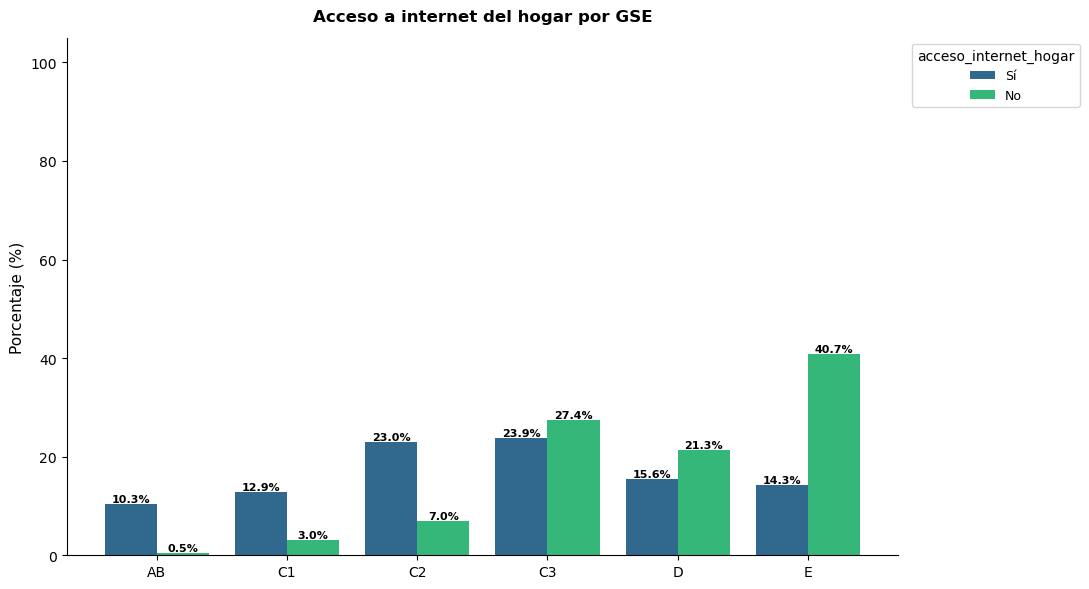

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'Acceso a internet del hogar por GSE'}, ylabel='Porcentaje (%)'>)

In [114]:
# Gráfico: Acceso × GSE
generar_grafico('gse', cruce='acceso_internet_hogar', factor='fe_hogar', 
                titulo='Acceso a internet del hogar por GSE')

## 14. Conectividad fija: tipo, velocidad, costo

Calidad y características del acceso en hogares conectados.

In [115]:
# Filtrar: solo hogares con acceso
df_acceso = df[df['acceso_internet_hogar'] == 'Sí'].copy()
print(f"Base: {df_acceso.shape[0]:,} hogares con acceso")

Base: 4,841 hogares con acceso


In [116]:
# Tipo de acceso fijo
dstats(df_acceso, 'tipo_acceso_fijo', tipo='frecuencia', factor='fe_hogar', estilo=True)

,n_ponderado,porcentaje
tipo_acceso_fijo,,
ADSL,"25,281",0.5
Acceso telefónico,"1,279",0.0
Antena,478,0.0
Banda ancha,"1,028",0.0
Cable/Módem,"1,080,610",19.8
Fibra óptica,"2,958,992",54.2
Inalámbrica,617,0.0
No sabe,"72,886",1.3
Satelital,"71,282",1.3


In [117]:
# Velocidad contratada
dstats(df_acceso, 'velocidad_contratada', tipo='frecuencia', factor='fe_hogar', estilo=True)

,n_ponderado,porcentaje
velocidad_contratada,,
Hasta 10 Mbps,"95,763",1.8
Más de 10 a 100 Mbps,"146,851",2.7
Más de 100 a 500 Mbps,"674,147",12.3
Más de 500 Mbps a 1 Gbps,"1,220,384",22.4
Más de 1 Gbps,"264,247",4.8
NS/NR,"1,739,704",31.9
Total,"4,141,096",75.9


In [118]:
# Velocidad × GSE (brecha de calidad)
dstats(df_acceso, 'velocidad_contratada', tipo='cruzada', cruce='gse', factor='fe_hogar', estilo=True)

,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
velocidad_contratada,,,,,,,,,,,,
Hasta 10 Mbps,"22,650",4.3,"11,228",1.8,"22,052",2.2,"20,229",2.2,"9,209",1.6,"10,394",2.1
Más de 10 a 100 Mbps,"9,415",1.8,"21,060",3.4,"49,889",4.9,"25,376",2.8,"22,554",3.9,"18,556",3.8
Más de 100 a 500 Mbps,"98,902",18.7,"126,294",20.7,"157,912",15.6,"118,740",12.9,"94,364",16.3,"77,935",15.9
Más de 500 Mbps a 1 Gbps,"196,200",37.0,"217,007",35.5,"316,871",31.3,"251,053",27.3,"128,022",22.1,"111,231",22.7
Más de 1 Gbps,"87,198",16.5,"30,995",5.1,"42,026",4.2,"56,661",6.2,"26,757",4.6,"20,610",4.2
NS/NR,"115,543",21.8,"204,763",33.5,"423,708",41.9,"447,005",48.6,"297,451",51.4,"251,234",51.3
Total,"529,908",100.0,"611,347",100.0,"1,012,458",100.0,"919,065",100.0,"578,357",100.0,"489,960",100.0


In [119]:
# Pago mensual internet — promedio por GSE
dstats(df_acceso, 'pago_mensual_internet', tipo='promedio', cruce='gse', factor='fe_hogar', estilo=True)

,pago_mensual_internet
gse,
AB,34646.6
C1,36131.9
C2,31017.4
C3,32422.7
D,28487.3
E,29480.5
Total,32019.4


In [120]:
# Tipo de plan
dstats(df_acceso, 'tipo_plan', tipo='frecuencia', factor='fe_hogar', estilo=True)

,n_ponderado,porcentaje
tipo_plan,,
BA + TV Cable,"1,687,868",30.9
BA + Telefonía fija,"59,003",1.1
Banda ancha desnuda,"1,891,831",34.7
Otros planes,"20,984",0.4
Triple pack (BA+TV+Tel),"481,409",8.8
Total,"4,141,096",75.9


In [121]:
# Razones para tener internet fijo (P6)
analizar_rm('P6', factor='fe_hogar', top_n=10, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,P6_3,Permite comunicarse con otras personas,"2,743,629",65.1
2,P6_2,Permite tener más acceso a información,"2,722,943",64.6
3,P6_6,"Permite acceder a entretenimiento a través de streaming de películas, series y música","2,374,191",56.3
4,P6_8,"Permite realizar trámites personales como revisar cuentas bancarias, realizar transferencias, solicitar certificados y pagar cuentas","2,293,789",54.4
5,P6_1,Apoyo a la educación propia o de hijos / nietos / parientes,"2,184,236",51.8
6,P6_12,Permite realizar trabajo o estudios desde casa,"2,059,723",48.9
7,P6_4,Permite participar en redes sociales y comunidades en línea,"2,037,782",48.4
8,P6_11,Proporciona acceso a noticias y actualidad,"1,937,760",46.0
9,P6_10,Facilita la realización de compras en línea y acceso a plataformas de comercio electrónico.,"1,787,205",42.4
10,P6_5,Permite acceder a juegos y otros medios de entretención,"1,576,958",37.4


In [122]:
# Medidas de protección para menores (P7)
analizar_rm('P7', factor='fe_hogar', top_n=8, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,P7_1,"Se acuerdan reglas sobre el uso de Internet (horarios, tiempo y condiciones)","768,069",49.8
2,P7_3,"Supervisión y/o monitoreo de uso de Internet (en presencia de adulto, verificar historial de navegación, etc.)","636,975",41.3
3,P7_5,"Educar a los niños sobre el uso seguro y responsable de Internet (ej: no publicar sus nombres completos en redes sociales, qué se puede hacer, cómo detectar relaciones / interacciones inseguras, etc.)","557,121",36.1
4,P7_7,Restricción o bloqueo de ciertas aplicaciones o plataformas en línea.,"393,412",25.5
5,P7_2,Instalación de filtros de Internet (software de control parental),"354,158",22.9
6,P7_10,Uso de controles parentales en los dispositivos conectados a internet.,"346,463",22.5
7,P7_11,No es necesario tener medidas de protección,"342,926",22.2
8,P7_9,Restricción de descargas o instalación de aplicaciones sin permiso.,"341,285",22.1


## 15. Uso individual de internet

Caracterizar usuarios vs. no-usuarios, frecuencia e intensidad.

In [123]:
# Último uso de internet
dstats(df, 'ultimo_uso_internet', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
ultimo_uso_internet,,
Hoy,"12,312,985",89.2
Entre 2 y 3 días,"800,229",5.8
Entre 3 y 7 días,"93,331",0.7
Entre 1 y 4 semanas,"56,325",0.4
Más de 4 semanas,"30,838",0.2
Más de 12 meses,"39,950",0.3
Nunca,"477,104",3.5
Total,"13,810,761",100.0


In [124]:
# Último uso × Edad
dstats(df, 'ultimo_uso_internet', tipo='cruzada', cruce='tramo_edad', factor='fe_personas', estilo=True)

,n Menor de 18,% Menor de 18,n 18-29,% 18-29,n 30-44,% 30-44,n 45-59,% 45-59,n 60 y más,% 60 y más
ultimo_uso_internet,,,,,,,,,,
Hoy,"160,467",96.9,"3,544,205",99.5,"4,023,907",97.6,"2,631,330",90.4,"1,953,077",64.0
Entre 2 y 3 días,"5,198",3.1,"15,044",0.4,"75,692",1.8,"188,795",6.5,"515,500",16.9
Entre 3 y 7 días,0,0.0,869,0.0,"1,906",0.1,"12,345",0.4,"78,210",2.6
Entre 1 y 4 semanas,0,0.0,"2,918",0.1,"6,808",0.2,"4,593",0.2,"42,005",1.4
Más de 4 semanas,0,0.0,0,0.0,"5,326",0.1,"4,552",0.2,"20,960",0.7
Más de 12 meses,0,0.0,0,0.0,"3,863",0.1,"20,413",0.7,"15,674",0.5
Nunca,0,0.0,0,0.0,"5,382",0.1,"47,819",1.6,"423,903",13.9
Total,"165,664",100.0,"3,563,036",100.0,"4,122,884",100.0,"2,909,848",100.0,"3,049,329",100.0


In [125]:
# Frecuencia de internet
dstats(df, 'frecuencia_internet', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
frecuencia_internet,,
Todos los días,"12,095,282",87.6
Varias veces por semana,"974,375",7.1
Al menos una vez al mes,"86,782",0.6
Menos de una vez al mes,"106,430",0.8
Total,"13,262,868",96.0


In [126]:
# Tiempo diario — promedio por GSE
dstats(df, 'tiempo_diario_internet', tipo='cruzada', cruce='gse', factor='fe_personas', estilo=True)

,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
tiempo_diario_internet,,,,,,,,,,,,
Menos de 1 hora,"18,637",1.3,"53,334",3.0,"219,942",7.6,"243,964",8.6,"210,327",12.1,"224,982",16.2
Entre 1 y 2 horas,"147,630",10.1,"193,723",11.0,"366,584",12.6,"526,502",18.6,"359,140",20.7,"237,748",17.1
Entre 2 y 4 horas,"266,980",18.2,"367,763",20.9,"498,500",17.1,"584,935",20.6,"325,750",18.8,"282,412",20.3
Más de 4 horas,"1,030,615",70.4,"1,141,300",65.0,"1,826,051",62.7,"1,481,791",52.2,"839,341",48.4,"647,329",46.5
Total,"1,463,861",100.0,"1,756,121",100.0,"2,911,078",100.0,"2,837,192",100.0,"1,734,559",100.0,"1,392,471",100.0


In [127]:
# Uso computador vs smartphone
dstats(df, 'uso_computador', tipo='cruzada', cruce='uso_smartphone', factor='fe_personas', estilo=True)

,n Sí,% Sí,n No,% No
uso_computador,,,,
Sí,"6,784,305",51.3,"71,072",11.9
No,"6,430,848",48.7,"524,535",88.1
Total,"13,215,153",100.0,"595,608",100.0


In [128]:
# Cómo aprendió a usar computador (Q6)
analizar_rm('Q6', factor='fe_personas', top_n=10, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q6_11,Aprendí solo,"5,200,919",37.7
2,Q6_3,"Era parte central de mi aprendizaje en el colegio, liceo, institución de educación superior (ej: parte del currículum de enseñanza de secretariado, contabilidad, ing. Informática, etc.)","4,024,733",29.1
3,Q6_7,No sé usar computador o nunca he usado un computador,"2,686,934",19.5
4,Q6_2,"Me enseñó un familiar, amigo o contacto","2,234,234",16.2
5,Q6_4,Aprendí en clases optativas o complementarias del colegio/ institución (no era parte central del currículum/ malla),"1,000,335",7.2
6,Q6_5,"Tomé un curso particular (clases particulares, curso en municipio, centro social, etc.)","707,521",5.1
7,Q6_10,En el trabajo,"176,745",1.3
8,Q6_6,Otro: Cuál?,"5,440",0.0
9,Q6_8,No usa,"5,842",0.0
10,Q6_9,No tiene,0,0.0


In [129]:
# Lugares donde usó internet ayer (Q11_1)
analizar_rm('Q11_1', factor='fe_personas', estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q11_1_1,En el hogar,"12,749,393",96.1
2,Q11_1_2,Lugar de trabajo (fuera del hogar),"2,740,324",20.7
3,Q11_1_7,"En la calle / plazas, espacios abiertos (con internet móvil del smartphone)","1,359,780",10.3
4,Q11_1_4,"En el hogar de otra persona (amigos, conocidos o parientes)","970,729",7.3
5,Q11_1_3,Lugar de educación / capacitación (fuera del hogar),"863,231",6.5
6,Q11_1_8,En medio de locomoción pública gratis (con internet móvil del smartphone),"671,370",5.1
7,Q11_1_9,En lugares cerrados sin acceso a redes de WiFi gratis (con internet móvil del smartphone),"544,259",4.1
8,Q11_1_6,"Lugares con red de WI-FI gratis (metro, restaurantes, café, estaciones de servicio, municipios, juntas de vecinos)","353,208",2.7
9,Q11_1_5,"En centros de internet pagados (por ejemplo, Cybercafé)","223,713",1.7


## 16. Actividades en internet

Mapear qué hacen los usuarios en línea, con desagregación demográfica.

In [130]:
# Top 15 actividades (Q21)
analizar_rm('Q21', factor='fe_personas', top_n=15, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q21_14,chatear por whatsapp,"11,584,087",87.3
2,Q21_11,realizar una llamada telefónica / videollamada por internet,"11,529,021",86.9
3,Q21_13,"utilizar redes sociales (facebook, twitter, linked-in, etc.)","10,095,006",76.1
4,Q21_12,enviar y/o recibir correos electrónicos,"9,637,286",72.7
5,Q21_34,realizar transacciones bancarias,"8,412,815",63.4
6,Q21_24,"ver películas, series y videos en línea (youtube, netflix, hbo, etc.)","8,196,036",61.8
7,Q21_36,"realizar pagos en línea de servicios básicos (agua, luz, telefonía, etc.)","6,490,418",48.9
8,Q21_21,descargar o escuchar música en línea por servicios de streaming (como spotify),"6,483,939",48.9
9,Q21_2,"obtener información acerca de bienes o servicios (precios, especificaciones, lugares de venta)","6,273,855",47.3
10,Q21_35,realzar compras de productos o servicios,"6,250,708",47.1


In [131]:
# Actividades × GSE (cruce demográfico)
analizar_rm_cruce('Q21', cruce='gse', factor='fe_personas')

,AB,C1,C2,C3,D,E
chatear por whatsapp,94.3,93.6,88.9,85.9,82.6,79.2
enviar y/o recibir correos electrónicos,91.2,86.4,76.6,67.7,64.2,52.3
realizar una llamada telefónica / videollamada por internet,89.8,89.4,88.7,88.8,84.2,78.0
"utilizar redes sociales (facebook, twitter, linked-in, etc.)",85.4,84.2,78.7,77.6,66.7,62.0
realizar transacciones bancarias,82.3,75.5,70.5,58.7,51.0,43.0
"ver películas, series y videos en línea (youtube, netflix, hbo, etc.)",76.0,73.0,65.2,61.2,55.1,39.0
realzar compras de productos o servicios,71.0,63.1,55.4,36.6,35.6,25.5
"realizar pagos en línea de servicios básicos (agua, luz, telefonía, etc.)",68.8,59.0,57.7,41.4,37.3,31.2
descargar o escuchar música en línea por servicios de streaming (como spotify),68.1,58.3,52.7,43.4,42.7,31.3
"obtener información acerca de bienes o servicios (precios, especificaciones, lugares de venta)",66.4,58.6,50.1,44.0,35.9,31.9


In [132]:
# Lugares donde usó internet fuera del hogar (Q20)
analizar_rm('Q20', factor='fe_personas', estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q20_1,Lugar de trabajo (fuera del hogar),"5,503,668",57.4
2,Q20_3,"En el hogar de otra persona (amigos, conocidos o parientes)","4,853,912",50.6
3,Q20_6,"En la calle / plazas, espacios abiertos (con internet móvil del smartphone)","3,937,817",41.1
4,Q20_2,Lugar de educación / capacitación (fuera del hogar),"2,549,894",26.6
5,Q20_7,En medio de locomoción pública gratis (con internet móvil del smartphone),"2,169,050",22.6
6,Q20_8,En lugares cerrados sin acceso a redes de WiFi gratis (con internet móvil del smartphone),"1,711,513",17.8
7,Q20_5,"Lugares con red de WI-FI gratis (metro, restaurantes, café, estaciones de servicio, municipios, juntas de vecinos)","1,150,129",12.0
8,Q20_4,"En centros de internet pagados (por ejemplo, Cybercafé)","478,218",5.0


## 17. Comercio electrónico y servicios digitales

Adopción de transacciones y servicios en línea.

In [133]:
# Última compra online
dstats(df, 'ultima_compra_online', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
ultima_compra_online,,
1.000000,"3,719,132",26.9
2.000000,"1,640,721",11.9
3.000000,"1,793,727",13.0
4.000000,"803,952",5.8
5.000000,"546,018",4.0
6.000000,"580,108",4.2
7.000000,"4,179,211",30.3
Total,"13,262,868",96.0


In [134]:
# Última compra × Edad
dstats(df, 'ultima_compra_online', tipo='cruzada', cruce='tramo_edad', factor='fe_personas', estilo=True)

,n Menor de 18,% Menor de 18,n 18-29,% 18-29,n 30-44,% 30-44,n 45-59,% 45-59,n 60 y más,% 60 y más
ultima_compra_online,,,,,,,,,,
1.000000,"21,490",13.0,"1,192,697",33.5,"1,573,083",38.3,"616,822",21.7,"315,039",12.2
2.000000,"5,195",3.1,"657,732",18.5,"508,279",12.4,"352,602",12.4,"116,914",4.5
3.000000,"12,750",7.7,"572,316",16.1,"678,645",16.5,"356,548",12.6,"173,468",6.7
4.000000,"31,842",19.2,"312,398",8.8,"256,304",6.2,"118,393",4.2,"85,015",3.3
5.000000,"3,134",1.9,"223,667",6.3,"121,088",3.0,"122,857",4.3,"75,272",2.9
6.000000,"28,063",16.9,"161,032",4.5,"161,098",3.9,"152,357",5.4,"77,559",3.0
7.000000,"63,191",38.1,"443,194",12.4,"809,817",19.7,"1,117,483",39.4,"1,745,525",67.4
Total,"165,664",100.0,"3,563,036",100.0,"4,108,313",100.0,"2,837,063",100.0,"2,588,791",100.0


In [135]:
# Bienes y servicios comprados (Q28) — top 12
analizar_rm('Q28', factor='fe_personas', top_n=12, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q28_4,"Ropa, zapatillas, artículos deportivos y accesorios","4,881,133",57.4
2,Q28_3,"Servicios de streaming de películas, series o música (Netflix, HBO, Spotify)","2,418,335",28.4
3,Q28_7,"Productos de belleza, higiene y cuidado personal.","2,171,653",25.5
4,Q28_6,Productos y artículos de limpieza para el hogar,"1,771,244",20.8
5,Q28_18,"Alimentos, bebidas y productos de despensa (compra de supermercado)","1,638,000",19.3
6,Q28_8,Medicamentos y productos farmacéuticos,"1,618,892",19.0
7,Q28_20,Servicios de entrega de comida a domicilio o para retirar,"1,460,329",17.2
8,Q28_19,"Servicios de transporte urbano (Uber, Didi, Cabify, etc.)","1,381,052",16.2
9,Q28_9,"Equipos de audio y tv, electrodomésticos,","1,344,967",15.8
10,Q28_10,"Muebles, decoración y artículos para el hogar","1,309,921",15.4


In [136]:
# Bienes comprados × GSE
analizar_rm_cruce('Q28', cruce='gse', factor='fe_personas')

,AB,C1,C2,C3,D,E
"Ropa, zapatillas, artículos deportivos y accesorios",71.2,58.2,55.4,54.9,46.0,59.1
"Servicios de streaming de películas, series o música (Netflix, HBO, Spotify)",38.3,35.0,25.5,22.0,30.4,19.3
Medicamentos y productos farmacéuticos,35.4,15.2,15.7,16.7,20.1,12.0
"Productos de belleza, higiene y cuidado personal.",32.2,26.1,24.3,27.1,19.5,21.5
"Alimentos, bebidas y productos de despensa (compra de supermercado)",32.0,19.2,18.3,15.3,16.6,12.9
"Servicios de transporte urbano (Uber, Didi, Cabify, etc.)",31.0,16.6,14.9,14.5,9.0,8.1
Servicios de entrega de comida a domicilio o para retirar,29.2,18.3,17.7,15.1,10.1,7.6
Productos y artículos de limpieza para el hogar,27.1,19.0,22.0,21.1,21.5,9.0
"Tickets/reservas para eventos de entretención (cine, deporte, teatro, conciertos, fiestas, etc.)",25.6,13.7,10.9,9.8,7.8,5.5
"Muebles, decoración y artículos para el hogar",24.5,14.4,15.8,11.8,14.9,9.8


## 18. Seguridad y privacidad digital

Percepciones y experiencias de riesgo en línea.

In [137]:
# Percepción de protección
dstats(df, 'percepcion_proteccion', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
percepcion_proteccion,,
Muy protegido,"1,531,333",11.1
Protegido,"6,175,436",44.7
Desprotegido,"4,017,412",29.1
Muy desprotegido,"1,071,701",7.8
NS/NR,"466,987",3.4
Total,"13,262,868",96.0


In [138]:
# Percepción × GSE
dstats(df, 'percepcion_proteccion', tipo='cruzada', cruce='gse', factor='fe_personas', estilo=True)

,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
percepcion_proteccion,,,,,,,,,,,,
Muy protegido,"300,947",19.8,"207,293",11.3,"406,466",12.9,"307,510",9.9,"182,773",9.3,"126,344",7.6
Protegido,"859,376",56.6,"957,276",52.1,"1,498,395",47.4,"1,401,823",45.0,"784,682",39.9,"673,885",40.5
Desprotegido,"299,265",19.7,"493,951",26.9,"963,593",30.5,"1,005,640",32.3,"687,106",34.9,"567,858",34.1
Muy desprotegido,"51,340",3.4,"135,788",7.4,"218,349",6.9,"287,685",9.2,"203,019",10.3,"175,520",10.5
NS/NR,"6,440",0.4,"43,769",2.4,"72,935",2.3,"112,125",3.6,"109,604",5.6,"122,114",7.3
Total,"1,517,367",100.0,"1,838,078",100.0,"3,159,738",100.0,"3,114,782",100.0,"1,967,183",100.0,"1,665,720",100.0


In [139]:
# Medidas de protección (Q32)
analizar_rm('Q32', factor='fe_personas', top_n=12, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q32_2,No descargar o abrir archivos o acceder a links sospechosos en correos electrónicos,"7,304,316",55.1
2,Q32_6,Cambio de contraseñas en cuentas y servicios en línea,"5,503,007",41.5
3,Q32_1,"Uso de algún tipo de herramienta de protección o software (antivirus, anti spam, firewall, etc.) para proteger su computador.","4,645,232",35.0
4,Q32_4,"Cambiar los ajustes de privacidad en una red social (por ejemplo, facebook, twitter, instagram, linkedin, etc)","4,245,614",32.0
5,Q32_5,"Borrar su historial de búsqueda en su navegador (por ejemplo, google)","4,035,344",30.4
6,Q32_3,Borrar o editar algo que usted posteó online para proteger su privacidad,"2,940,688",22.2
7,Q32_18,Ninguna de las anteriores/NINGUNA,"2,841,711",21.4
8,Q32_7,NET OTROS,"78,504",0.6
9,Q32_8,Otro,"24,537",0.2
10,Q32_9,Bloqueo de llamadas,"14,992",0.1


In [140]:
# Problemas de seguridad (Q33)
analizar_rm('Q33', factor='fe_personas', estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q33_5,Ninguno de los anteriores,"10,408,383",78.5
2,Q33_1,"Ataque de algún virus (troyano o gusano) que ha dado como resultado pérdida de datos o tiempo, o daño al software o al equipo","1,445,880",10.9
3,Q33_3,Pérdidas financieras debido a pagos fraudulentos con tarjetas de créditos o débitos,"802,518",6.1
4,Q33_2,"Mal uso de información personal en internet (mal uso de videos, fotos o datos personales subidos a sitios públicos)","789,785",6.0
5,Q33_4,Suplantación de identidad en trámites o compras,"437,211",3.3
6,Q33_6,NET OTROS,"130,319",1.0
7,Q33_9,Las llamadas telefónicas /ESTAFAS,"46,056",0.3
8,Q33_10,Hackeo,"34,894",0.3
9,Q33_8,Mucho Spam en llamadas,"27,654",0.2
10,Q33_7,Otro,"12,608",0.1


In [141]:
# Incidentes de seguridad × GSE (vulnerabilidad diferencial)
analizar_rm_cruce('Q33', cruce='gse', factor='fe_personas')

,AB,C1,C2,C3,D,E
Ninguno de los anteriores,84.6,81.0,76.8,78.5,75.6,76.6
"Ataque de algún virus (troyano o gusano) que ha dado como resultado pérdida de datos o tiempo, o daño al software o al equipo",6.3,11.7,11.4,11.5,11.7,11.2
"Mal uso de información personal en internet (mal uso de videos, fotos o datos personales subidos a sitios públicos)",5.3,3.1,5.9,6.3,7.5,7.4
Pérdidas financieras debido a pagos fraudulentos con tarjetas de créditos o débitos,4.1,6.1,7.8,4.2,7.9,5.6
NET OTROS,1.3,0.6,1.6,0.6,0.4,1.3
Suplantación de identidad en trámites o compras,0.9,1.1,4.0,3.9,4.3,4.4
Sobrecarga de publicidad /oferta,0.7,0.0,0.0,0.0,0.0,0.0
Hackeo,0.5,0.2,0.2,0.5,0.1,0.1
Las llamadas telefónicas /ESTAFAS,0.1,0.0,0.9,0.1,0.2,0.6
Otro,0.0,0.0,0.2,0.0,0.1,0.3


In [142]:
# Razones de no uso (Q34)
analizar_rm('Q34', factor='fe_personas', top_n=12, estilo=True)

,variable,etiqueta,n_ponderado,porcentaje
1,Q34_1,NET RELEVANCIA,"340,780",62.2
2,Q34_5,NET USABILIDAD,"253,406",46.3
3,Q34_3,No lo necesito / no me sirve,"204,398",37.3
4,Q34_6,No sé utilizar el computador y/o Smartphone,"169,062",30.9
5,Q34_7,No sé cómo utilizar el Internet,"125,225",22.9
6,Q34_4,No le interesa utilizar internet por razones distintas a la utilidad que tiene para usted.,"120,278",22.0
7,Q34_2,No sé bien para qué sirve el Internet / no sé cuáles son los beneficios,"108,994",19.9
8,Q34_12,NET COSTO DE SERVICIO,"60,616",11.1
9,Q34_14,La conexión a Internet es muy cara,"58,218",10.6
10,Q34_8,No creo que sea capaz de aprender a usar el internet,"53,138",9.7


## 19. Percepciones sobre internet

Actitudes hacia internet como determinante de adopción.

In [143]:
# Internet mejora la vida
dstats(df, 'internet_mejora_vida', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
internet_mejora_vida,,
Sí,"4,264,155",30.9
No,"1,190,316",8.6
Total,"5,454,471",39.5


In [144]:
# Internet mejora vida × GSE
dstats(df, 'internet_mejora_vida', tipo='cruzada', cruce='gse', factor='fe_personas', estilo=True)

,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
internet_mejora_vida,,,,,,,,,,,,
Sí,"689,350",75.3,"832,532",82.4,"979,841",73.4,"782,457",78.1,"601,147",85.4,"378,827",77.7
No,"226,188",24.7,"178,271",17.6,"355,591",26.6,"219,301",21.9,"102,476",14.6,"108,489",22.3
Total,"915,538",100.0,"1,010,804",100.0,"1,335,432",100.0,"1,001,758",100.0,"703,623",100.0,"487,315",100.0


In [145]:
# Internet mejora vida × Edad
dstats(df, 'internet_mejora_vida', tipo='cruzada', cruce='tramo_edad', factor='fe_personas', estilo=True)

,n Menor de 18,% Menor de 18,n 18-29,% 18-29,n 30-44,% 30-44,n 45-59,% 45-59,n 60 y más,% 60 y más
internet_mejora_vida,,,,,,,,,,
Sí,"72,588",76.6,"1,446,735",83.3,"1,662,298",78.8,"727,200",73.6,"355,334",67.5
No,"22,121",23.4,"290,241",16.7,"446,485",21.2,"260,679",26.4,"170,790",32.5
Total,"94,709",100.0,"1,736,976",100.0,"2,108,783",100.0,"987,878",100.0,"526,124",100.0


In [146]:
# Internet mejora vida × Zona
dstats(df, 'internet_mejora_vida', tipo='cruzada', cruce='zona', factor='fe_personas', estilo=True)

,n Urbana,% Urbana,n Rural,% Rural
internet_mejora_vida,,,,
Sí,"3,847,905",78.2,"416,250",78.3
No,"1,074,677",21.8,"115,639",21.7
Total,"4,922,581",100.0,"531,889",100.0


In [147]:
# Internet facilita trabajo
dstats(df, 'internet_facilita_trabajo', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
internet_facilita_trabajo,,
Sí,"10,057,051",72.8
No,"3,205,817",23.2
Total,"13,262,868",96.0


In [148]:
# Internet facilita trabajo × GSE
dstats(df, 'internet_facilita_trabajo', tipo='cruzada', cruce='gse', factor='fe_personas', estilo=True)

,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
internet_facilita_trabajo,,,,,,,,,,,,
Sí,"1,362,876",89.8,"1,600,098",87.0,"2,448,137",77.5,"2,143,282",68.8,"1,437,659",73.1,"1,064,998",63.9
No,"154,491",10.2,"237,980",12.9,"711,600",22.5,"971,500",31.2,"529,524",26.9,"600,722",36.1
Total,"1,517,367",100.0,"1,838,078",100.0,"3,159,738",100.0,"3,114,782",100.0,"1,967,183",100.0,"1,665,720",100.0


## 20. Ampliar análisis de habilidades digitales

Profundizar sección 11 con cruces demográficos.

In [149]:
# Distribución de nivel_habilidades
dstats(df, 'nivel_habilidades', tipo='frecuencia', factor='fe_personas', estilo=True)

,n_ponderado,porcentaje
nivel_habilidades,,
Avanzado,"5,681,644",41.1
Básico,"1,585,020",11.5
Intermedio,"5,710,998",41.4
Sin habilidades,"833,099",6.0
Total,"13,810,761",100.0


In [150]:
# Nivel de habilidades × GSE
dstats(df, 'nivel_habilidades', tipo='cruzada', cruce='gse', factor='fe_personas', estilo=True)

,n AB,% AB,n C1,% C1,n C2,% C2,n C3,% C3,n D,% D,n E,% E
nivel_habilidades,,,,,,,,,,,,
Avanzado,"1,070,430",70.3,"1,138,402",61.7,"1,501,843",46.9,"990,034",30.4,"581,458",27.7,"399,477",21.1
Básico,"56,139",3.7,"39,977",2.2,"223,190",7.0,"416,856",12.8,"406,274",19.4,"442,583",23.4
Intermedio,"390,950",25.7,"637,097",34.5,"1,406,146",43.9,"1,632,073",50.2,"922,664",44.0,"722,069",38.2
Sin habilidades,"4,490",0.3,"30,457",1.6,"72,620",2.3,"212,409",6.5,"185,579",8.8,"327,543",17.3
Total,"1,522,010",100.0,"1,845,934",100.0,"3,203,799",100.0,"3,251,371",100.0,"2,095,975",100.0,"1,891,672",100.0


In [151]:
# Nivel de habilidades × Tramo de edad
dstats(df, 'nivel_habilidades', tipo='cruzada', cruce='tramo_edad', factor='fe_personas', estilo=True)

,n Menor de 18,% Menor de 18,n 18-29,% 18-29,n 30-44,% 30-44,n 45-59,% 45-59,n 60 y más,% 60 y más
nivel_habilidades,,,,,,,,,,
Avanzado,"128,089",77.3,"2,150,776",60.4,"2,181,706",52.9,"881,240",30.3,"339,834",11.1
Básico,"2,004",1.2,"83,236",2.3,"137,680",3.3,"418,759",14.4,"943,340",30.9
Intermedio,"35,572",21.5,"1,314,801",36.9,"1,739,831",42.2,"1,477,166",50.8,"1,143,629",37.5
Sin habilidades,0,0.0,"14,223",0.4,"63,667",1.5,"132,683",4.6,"622,526",20.4
Total,"165,664",100.0,"3,563,036",100.0,"4,122,884",100.0,"2,909,848",100.0,"3,049,329",100.0


In [152]:
# Nivel de habilidades × Educación grupo
dstats(df, 'nivel_habilidades', tipo='cruzada', cruce='educ_grupo', factor='fe_personas', estilo=True)

,n Básica o menos,% Básica o menos,n Media,% Media,n Superior,% Superior
nivel_habilidades,,,,,,
Avanzado,"136,801",8.9,"1,536,121",26.3,"4,008,722",62.2
Básico,"592,836",38.6,"808,630",13.8,"183,554",2.9
Intermedio,"406,282",26.5,"3,119,685",53.5,"2,185,032",33.9
Sin habilidades,"398,254",26.0,"371,984",6.4,"62,860",1.0
Total,"1,534,173",100.0,"5,836,419",100.0,"6,440,169",100.0


In [153]:
# Nivel de habilidades × Zona
dstats(df, 'nivel_habilidades', tipo='cruzada', cruce='zona', factor='fe_personas', estilo=True)

,n Urbana,% Urbana,n Rural,% Rural
nivel_habilidades,,,,
Avanzado,"5,125,693",42.4,"555,951",32.5
Básico,"1,337,440",11.1,"247,580",14.5
Intermedio,"4,943,309",40.9,"767,689",44.9
Sin habilidades,"695,239",5.7,"137,860",8.1
Total,"12,101,681",100.0,"1,709,080",100.0


In [154]:
# Habilidades específicas (Q8) × Sexo
hab_x_sexo = analizar_rm_cruce('Q8', cruce='sexo', factor='fe_personas', estilo=False)
hab_x_sexo

,Hombre,Mujer
"Revisar redes sociales (Facebook, Instagram, Whatapps, Youtube, TikTok, etc)",84.2,85.6
Realizar videollamdas,82.8,86.8
Enviar y recibir correos con o sin archivos adjuntos,76.5,70.9
"Realizar transacciones bancarias, compras y pagos en línea",73.0,70.5
Uso de procesador de texto (ej: Word),64.8,54.4
Editar fotografías o videos,63.8,59.9
Subir contenidos o realizar posteos en redes sociales,60.7,54.9
"Duplicar o transferir archivos entre dispositivos (cámaras digitales, celulares, reproductores de música) o en la nube",59.8,47.7
"Encontrar, descargar e instalar y configurar aplicaciones (Apps) y/o programas (softwares) desde internet",59.7,45.4
"Conectar un nuevo dispositivo (como un router, cámara o impresora)",59.3,46.6


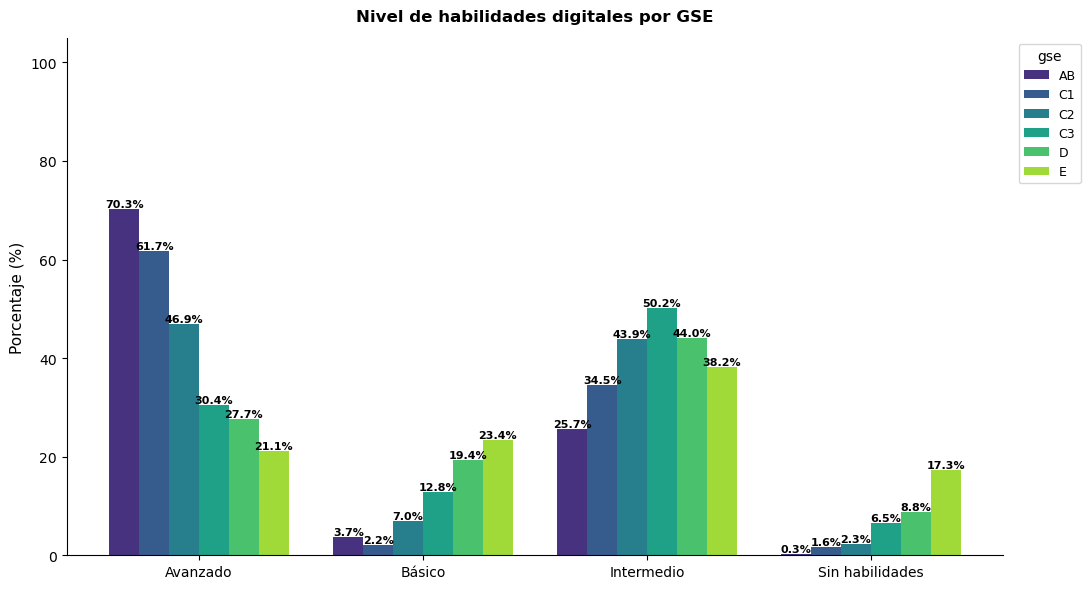

(<Figure size 1100x600 with 1 Axes>,
 <Axes: title={'center': 'Nivel de habilidades digitales por GSE'}, ylabel='Porcentaje (%)'>)

In [155]:
# Gráfico: Nivel de habilidades por GSE
generar_grafico('nivel_habilidades', cruce='gse', factor='fe_personas',
                titulo='Nivel de habilidades digitales por GSE', tipo='bar')

In [163]:
dstats(df, 'tipo_acceso_mas_usado', tipo='frecuencia', factor='fe_hogar')

,n_ponderado,porcentaje
tipo_acceso_mas_usado,,
1.000000,"1,405,744",24.9
2.000000,"64,280",1.1
3.000000,"1,583,647",28.0
4.000000,"12,622",0.2
Total,"3,066,294",54.2


In [164]:
acceso_dist = dstats(df, 'tipo_acceso_mas_usado',                                                                     
                        tipo='frecuencia',                                                                              
                        factor='fe_hogar',                                                                              
                        estilo=True) 

In [165]:
acceso_dist

,n_ponderado,porcentaje
tipo_acceso_mas_usado,,
1.000000,"1,405,744",24.9
2.000000,"64,280",1.1
3.000000,"1,583,647",28.0
4.000000,"12,622",0.2
Total,"3,066,294",54.2


In [170]:
# Ver qué etiquetas tiene Q13                                                            
print("Q13 valores únicos:")                                                                                          
print(df['Q13'].value_counts(dropna=False))                                                                           
print("\nQ13 dtype:", df['Q13'].dtype)                                                                                
                                                                                                                      
# Ver qué tiene tipo_acceso_mas_usado                                                                               
print("\n\ntipo_acceso_mas_usado valores únicos:")                                                                    
print(df['tipo_acceso_mas_usado'].value_counts(dropna=False))                                                         
print("tipo_acceso_mas_usado dtype:", df['tipo_acceso_mas_usado'].dtype)                                            
                                                                                                                      
# Ver si Q13 está en etiquetas_limpias                                                                              
if 'Q13' in etiquetas_limpias:                                                                                        
    print("\n\nEtiquetas Q13:")                                                                                       
    print(etiquetas_limpias['Q13'])  

Q13 valores únicos:


KeyError: 'Q13'